<p style="font-size:300%; background-color:#ffe6f0; color:#0044cc; text-align:center; line-height:80px; margin:0; padding:0;"> <b>Algoritmos Genéticos</b> 
</p>

<p style="font-size:240%; background-color:#ffe6f0; color:#cc0000; text-align:center; line-height:60px; margin:0; padding:0;">
  <b>Técnicas de Inteligencia Artificial</b>
</p>

<p style="font-size:200%; text-align:center; line-height:40px; margin:0;">
  <br><b>Prof. Flavio Prieto</b>
</p>

<p style="font-size:160%; text-align:center; line-height:25px; margin:0;">
  email: <a href="mailto:faprietoo@unal.edu.co">faprietoo@unal.edu.co</a>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  <br><b>DEPARTAMENTO DE INGENIERÍA MECÁNICA Y MECATRÓNICA</b>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  Facultad de Ingeniería
</p>

<p style="font-size:160%; text-align:center; line-height:30px; margin:0;">
  Universidad Nacional de Colombia – Sede Bogotá
</p>

<div style="text-align:center; margin-top:20px; margin-bottom:10px;">
  <img src="Fig/Escudo_UN.png" alt="Escudo UNAL" width="90" style="border:none;">
</div>



**Ejemplos tomados de https:** //github.com/PacktPublishing/Hands-On-Genetic-Algorithms-with-Python/blob/master/Chapter03/01-OneMax-long.py

<div style="border: 2px solid #4CAF50; padding: 5px; border-radius: 4px; background-color: #e8f5e9; text-align: center;">
</div>

# **Problema One-Max**

Dado un vector binario de longitud 100, encontrar el individuo con la mayor cantidad de 1s posible.

Formalmente:

> Maximizar
> $f(x) = \sum_{i=1}^{100} x_i$

donde: $x_i \in \{0,1\}$



In [1]:
from deap import base
from deap import creator
from deap import tools

import random

import matplotlib.pyplot as plt
import seaborn as sns

## **Constantes**

In [2]:
# problem constants:
ONE_MAX_LENGTH = 100  # Define que cada individuo será una lista de 100 bits (0 o 1).

# Genetic Algorithm constants:
POPULATION_SIZE = 200  # 200 individuos por generación.
P_CROSSOVER = 0.9  # 90% de probabilidad de aplicar cruce.
P_MUTATION = 0.1   # 10% de probabilidad de mutar un individuo.
MAX_GENERATIONS = 50 # 50 generaciones máximo.


# set the random seed:
# Esto fija la semilla para asegurar resultados reproducibles.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)


# DEAP usa toolbox como un contenedor de funciones registradas.
# Toolbox permite asociar nombres con operadores genéticos.
toolbox = base.Toolbox()

## Preliminares

### Define una función dentro del toolbox llamada "zeroOrOne" que devuelve 0 o 1 aleatoriamente.

- Registra una función en el toolbox llamada "zeroOrOne"
En DEAP, toolbox.register permite crear funciones reutilizables que luego se usan para generar individuos, poblaciones, etc.

Aquí se crea la función:
> toolbox.zeroOrOne()

- Esa función ejecutará random.randint(0, 1)

> random.randint(0, 1) devuelve un número entero al azar entre 0 y 1, ambos incluidos.

Es decir, genera un bit aleatorio.


In [3]:
toolbox.register("zeroOrOne", random.randint, 0, 1)

### Definición de la estrategia de aptitud (Fitness)

```python
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
```

- **Explicación:**
Esta instrucción crea una nueva clase llamada FitnessMax que **se utilizará para evaluar individuos**.

- **¿Qué significa?**
Hereda de base.Fitness, la clase base que maneja valores de aptitud.

- Se le asigna un parámetro:
```python
weights = (1.0,)
```

- **Esto indica**
    - Hay un solo objetivo de optimización.
    - Ese objetivo debe maximizarse, porque el peso es positivo.

> **Nota**
> Si se quisiera **minimizar un objetivo**, el peso debería ser negativo:
> weights = (-1.0,)

In [4]:

creator.create("FitnessMax", base.Fitness, weights=(1.0,))

### Creación de la clase `Individual` en DEAP

La siguiente línea define la estructura básica de un individuo dentro del algoritmo genético:

```python
creator.create("Individual", list, fitness=creator.FitnessMax)
```

Esto significa:

- **`Individual` será una nueva clase creada dinámicamente por DEAP.**
- **Hereda de `list`**, por lo que cada individuo es simplemente una lista de valores  
  (por ejemplo, bits 0/1 en el problema *OneMax*).
- **Se le añade automáticamente un atributo `fitness`**, cuyo tipo es `FitnessMax`,  
  definido previamente para manejar un objetivo de maximización.

En otras palabras, esta línea **especifica cómo se representará cada cromosoma** en el algoritmo genético:  
**una estructura tipo lista con un campo de aptitud asociado.**


> **La instrucción:**
> creator.create("Individual", array.array, typecode='b', fitness=creator.FitnessMax)
> 
> Usa un array('b') (arreglo de enteros pequeños), lo que puede ser más eficiente en memoria, aunque con menos flexibilidad que una lista estándar.

In [5]:
# create the Individual class based on list:

creator.create("Individual", list, fitness=creator.FitnessMax)
#creator.create("Individual", array.array, typecode='b', fitness=creator.FitnessMax)  # Permite usar un array('b') en lugar de una lista, más eficiente.

### Creación y uso del operador `individualCreator`

El siguiente código registra una función dentro del `toolbox` llamada `individualCreator`, cuya tarea es generar un individuo válido para el algoritmo genético:

```python
toolbox.register(
    "individualCreator",
    tools.initRepeat,
    creator.Individual,
    toolbox.zeroOrOne,
    ONE_MAX_LENGTH
)
```

Esto hace que:

- **`tools.initRepeat`** repita una operación varias veces.
- El resultado sea un objeto **`creator.Individual`**, es decir, un individuo DEAP basado en una lista.
- Cada posición del individuo se genere con **`toolbox.zeroOrOne`**, que devuelve aleatoriamente 0 o 1.
- **`ONE_MAX_LENGTH`** defina la cantidad de genes (por ejemplo, 100 bits).

In [6]:
# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initRepeat, creator.Individual, toolbox.zeroOrOne, ONE_MAX_LENGTH)


#----------------------------------------------------------------------------------
# Se crea un nuevo individuo, se imprime su tamaño y se muestra su contenido.
# El resultado es un vector binario de longitud 100 compuesto por valores 0 y 1 generados aleatoriamente.

ind = toolbox.individualCreator()
print("\nTamaño del individuo: ",len(ind))
print("Individuo:\n", ind)


Tamaño del individuo:  100
Individuo:
 [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1]


### Creación del operador `populationCreator` y visualización de la población

La siguiente línea registra en el `toolbox` una función llamada **`populationCreator`**:

```python
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)
```

Esto significa:

- Se crea una **lista Python (`list`)** que representará la población.
- Esa lista se llena aplicando repetidamente **`individualCreator`**, es decir, generando individuos uno por uno.
- El número de individuos se especifica cuando se llama posteriormente:  
  `population = toolbox.populationCreator(n=POPULATION_SIZE)`
- Por lo tanto, esta función construye la **población inicial completa** del algoritmo genético.


In [7]:
# create the population operator to generate a list of individuals:

toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)


#----------------------------------------------------------------------------------
# Tamaño de la población
population = toolbox.populationCreator(n=POPULATION_SIZE)
print("Tamaño de la población:", len(population))

# Mostrar algunos individuos
print("\nPrimeros 5 individuos:")
for i in range(5):
    print(f"Individuo {i}:", population[i], "   tamaño:", len(population[i]))


Tamaño de la población: 200

Primeros 5 individuos:
Individuo 0: [1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0]    tamaño: 100
Individuo 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0]    tamaño: 100
Individuo 2: [0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 

## **Función de aptitud (fitness)**

La función `oneMaxFitness` calcula el *fitness* del individuo contando cuántos genes valen 1.  

- `individual` es una lista de bits (0/1).
- `sum(individual)` cuenta cuántos 1 tiene el individuo: $f(\text{individuo}) = \sum_{i=1}^{n} x_i$.
- El retorno incluye una coma al final para convertirlo en una tupla, porque **DEAP requiere que el fitness sea un iterable**, incluso si solo tiene un valor.

**Ejemplo**:  
Si el individuo es `[1, 0, 1, 1]` → `fitness = (3,)`.

In [8]:
# fitness calculation:
# compute the number of '1's in the individual
def oneMaxFitness(individual):
    return sum(individual),  # return a tuple


toolbox.register("evaluate", oneMaxFitness)

## **Operadores Genéticos**

### Registro del **operador de selección** por torneo

```python
toolbox.register("select", tools.selTournament, tournsize=3)
```

Esto significa:

- Se crea un **operador llamado `select`** en el `toolbox`.
- Usa la función **`selTournament`** de DEAP, que implementa **selección por torneo**.
- `tournsize=3` indica que cada torneo se realiza entre **3 individuos seleccionados aleatoriamente**.
- El ganador de cada torneo (el de mayor fitness) será seleccionado para la siguiente generación.

> En otras palabras, este operador permite elegir los individuos que participarán en el **cruce y la mutación**, manteniendo presión selectiva y diversidad en la población.


In [9]:
# genetic operators:

# Tournament selection with tournament size of 3:
toolbox.register("select", tools.selTournament, tournsize=3)

### Registro del **operador de cruce** de un solo punto

```python
toolbox.register("mate", tools.cxOnePoint)
```

Esto significa:

- Se crea un **operador llamado `mate`** en el `toolbox`.
- Usa la función **`cxOnePoint`** de DEAP, que implementa **cruce de un solo punto**.
- El operador selecciona un punto aleatorio en los cromosomas de dos individuos padres y **intercambia las secciones posteriores** entre ellos para generar dos hijos.

### Ejemplo de cruce de un solo punto (One-Point Crossover)

| Individuo | Genes                       |
|------------|-----------------------------|
| **Padre 1** | 1 0 1 \| 0 1            |
| **Padre 2** | 0 0 0 \| 1 1            |
| **Hijo 1**  | 1 0 1 \| 1 1            |
| **Hijo 2**  | 0 0 0 \| 0 1            |

- La barra `|` indica el **punto de cruce**.
- Los segmentos posteriores al punto de cruce se **intercambian** entre los padres.
- Los hijos resultantes combinan información genética de ambos padres, promoviendo diversidad.


> En otras palabras, este operador combina información genética de dos padres para generar descendencia, promoviendo diversidad y exploración en el espacio de soluciones.

In [10]:
# Single-point crossover:
toolbox.register("mate", tools.cxOnePoint)

### Registro del operador de mutación Flip-Bit

```python
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/ONE_MAX_LENGTH)
```

Esto significa:

- Se crea un **operador llamado `mutate`** en el `toolbox`.
- Usa la función **`mutFlipBit`** de DEAP, que implementa **mutación de bits individuales**.
- `indpb=1.0/ONE_MAX_LENGTH` indica la **probabilidad independiente de mutar cada gen**:
  - Si la longitud del individuo es `ONE_MAX_LENGTH` (por ejemplo, 100),  
    cada bit tiene probabilidad **1/100** de invertirse (0 ↔ 1).

> En otras palabras, este operador introduce **variación genética** de manera controlada, alterando aleatoriamente algunos bits del individuo para explorar nuevas soluciones.


In [11]:
# Flip-bit mutation:
# indpb: Independent probability for each attribute to be flipped
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/ONE_MAX_LENGTH)

## Flujo del Algoritmo Genético (Genetic Algorithm Flow)

1. **Inicialización de la población**: Crear una población inicial de individuos aleatorios usando `populationCreator`.
2. **Evaluación de la aptitud (fitness)**: Calcular el valor de aptitud de cada individuo con la función registrada `evaluate`.
3. **Bucle evolutivo** (repetir hasta cumplir un criterio de parada):
   - **Selección**: Elegir individuos padres usando `select` (por ejemplo, selección por torneo).
   - **Cruce (crossover)**: Combinar padres usando `mate` (por ejemplo, cruce de un punto) para generar descendencia.
   - **Mutación**: Aplicar `mutate` a la descendencia para introducir variación genética.
   - **Evaluación de descendencia**: Calcular fitness de los nuevos individuos.
   - **Reemplazo**: Sustituir la población actual por la nueva generación.
4. **Registro de estadísticas**: Guardar y, opcionalmente, graficar valores máximos y promedio de fitness por generación.
5. **Resultado final**: Seleccionar y mostrar el mejor individuo encontrado.


### Creación de la población inicial (Generación 0)

```python
population = toolbox.populationCreator(n=POPULATION_SIZE)
generationCounter = 0
```

Esto significa:

- Se crea la **población inicial** llamando a `populationCreator` con el tamaño definido por `POPULATION_SIZE` (por ejemplo, 200 individuos).
- Cada individuo en la población es un objeto **`Individual`** generado aleatoriamente.
- Se inicializa el **contador de generaciones** `generationCounter` en 0, indicando que recién empieza la evolución.


In [12]:
# create initial population (generation 0):
population = toolbox.populationCreator(n=POPULATION_SIZE)
generationCounter = 0

### Cálculo de la aptitud y preparación de estadísticas

```python
fitnessValues = list(map(toolbox.evaluate, population))
for individual, fitnessValue in zip(population, fitnessValues):
    individual.fitness.values = fitnessValue
```

- **Calcular la aptitud de cada individuo**:
    - `toolbox.evaluate` llama a la función de fitness registrada (`oneMaxFitness`), que en este caso cuenta el número de `1`s en el individuo.
    - `map` aplica esta función a todos los individuos de la población.
    - Se obtiene una lista de valores de aptitud (`fitnessValues`).


```python
fitnessValues = [individual.fitness.values[0] for individual in population]
```

- **Extraer los valores de aptitud como lista simple**:
    - Se crea una lista `fitnessValues` con los valores numéricos de cada individuo, para facilitar estadísticas.



```python
maxFitnessValues = []
meanFitnessValues = []
```

- **Inicializar acumuladores de estadísticas**:
  - `maxFitnessValues` y `meanFitnessValues` se usarán para almacenar los valores máximo y promedio de fitness por generación, para seguimiento y visualización.

In [13]:
# calculate fitness tuple for each individual in the population:
fitnessValues = list(map(toolbox.evaluate, population))
for individual, fitnessValue in zip(population, fitnessValues):
    individual.fitness.values = fitnessValue

# extract fitness values from all individuals in population:
fitnessValues = [individual.fitness.values[0] for individual in population]

# initialize statistics accumulators:
maxFitnessValues = []
meanFitnessValues = []

### Bucle evolutivo principal del Algoritmo Genético

El bucle principal del algoritmo genético se ejecuta mientras **no se alcance el máximo fitness posible** ni se supere el **número máximo de generaciones**. En cada iteración se realiza lo siguiente:

1. **Incremento del contador de generaciones**: Se actualiza `generationCounter` para llevar control de la evolución.

2. **Selección de padres**: Se aplican operadores de selección (por ejemplo, torneo) para elegir los individuos que participarán en la reproducción.

3. **Clonación de los individuos seleccionados**: Se clonan los individuos seleccionados para asegurar que los cambios futuros no modifiquen la población original directamente.

4. **Cruce (crossover)**: Se aplican operadores de cruce por pares de individuos (por ejemplo, cruce de un solo punto) con una probabilidad definida (`P_CROSSOVER`). Tras el cruce, se eliminan los valores de fitness para recalcularlos posteriormente.

5. **Mutación**: Cada individuo de la descendencia puede sufrir mutación de manera independiente con probabilidad `P_MUTATION`. Los genes seleccionados se alteran (por ejemplo, se invierte un bit) y se elimina el valor de fitness para recalcularlo.

6. **Evaluación de nuevos individuos**: Se calcula el fitness únicamente de los individuos cuya aptitud ya no es válida (es decir, que fueron modificados por cruce o mutación).

7. **Reemplazo de la población**: La población actual se reemplaza por la descendencia recién generada.

8. **Registro de estadísticas**: Se actualizan listas que guardan el **fitness máximo** y el **fitness promedio** de la generación, para su análisis y visualización.

9. **Impresión del mejor individuo**: Se identifica y muestra el individuo con mayor fitness de la generación, permitiendo seguir la evolución de las soluciones a lo largo del tiempo.

En conjunto, este bucle implementa la **evolución iterativa**: selección de los mejores, recombinación genética, mutación y evaluación, repitiéndose hasta alcanzar la solución óptima o agotar las generaciones permitidas.


In [14]:
# main evolutionary loop:
# stop if max fitness value reached the known max value
# OR if number of generations exceeded the preset value:
while max(fitnessValues) < ONE_MAX_LENGTH and generationCounter < MAX_GENERATIONS:
    # update counter:
    generationCounter = generationCounter + 1

    # apply the selection operator, to select the next generation's individuals:
    offspring = toolbox.select(population, len(population))
    # clone the selected individuals:
    offspring = list(map(toolbox.clone, offspring))

    # apply the crossover operator to pairs of offspring:
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < P_CROSSOVER:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    for mutant in offspring:
        if random.random() < P_MUTATION:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # calculate fitness for the individuals with no previous calculated fitness value:
    freshIndividuals = [ind for ind in offspring if not ind.fitness.valid]
    freshFitnessValues = list(map(toolbox.evaluate, freshIndividuals))
    for individual, fitnessValue in zip(freshIndividuals, freshFitnessValues):
        individual.fitness.values = fitnessValue

    # replace the current population with the offspring:
    population[:] = offspring

    # collect fitnessValues into a list, update statistics and print:
    fitnessValues = [ind.fitness.values[0] for ind in population]

    maxFitness = max(fitnessValues)
    meanFitness = sum(fitnessValues) / len(population)
    maxFitnessValues.append(maxFitness)
    meanFitnessValues.append(meanFitness)
    print("- Generation {}: Max Fitness = {}, Avg Fitness = {}".format(generationCounter, maxFitness, meanFitness))

    # find and print best individual:
    best_index = fitnessValues.index(max(fitnessValues))
    print("Best Individual = ", *population[best_index], "\n")

- Generation 1: Max Fitness = 66.0, Avg Fitness = 54.89
Best Individual =  1 1 0 1 1 1 0 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 0 1 1 0 1 1 1 1 0 0 1 1 1 1 0 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 0 0 1 0 1 0 1 1 0 0 1 1 1 0 1 1 0 0 1 1 1 0 1 0 1 0 1 1 

- Generation 2: Max Fitness = 68.0, Avg Fitness = 58.305
Best Individual =  0 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 0 1 1 0 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 0 1 0 1 1 1 0 1 1 1 

- Generation 3: Max Fitness = 70.0, Avg Fitness = 62.13
Best Individual =  1 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 0 1 1 1 0 1 1 0 0 0 1 0 1 1 0 1 0 1 0 1 1 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1 0 1 1 1 0 1 1 1 0 0 1 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 

- Generation 4: Max Fitness = 74.0, Avg Fitness = 64.945
Best Individual =  1 1 1 1 1 1 0 0 1 1 0 1 1 1 1 0 0 1 1 0 1 1 0 1 1 1 1 1 0 1 0 1 1 1 0 0 1 0 0 1 1 1 1 1 0 1 

### Visualización de estadísticas del Algoritmo Genético

Al finalizar el algoritmo genético, se grafican las estadísticas acumuladas durante la evolución:

- Se establece un estilo de gráfico con **`sns.set_style("whitegrid")`** para mayor claridad.
- Se dibujan dos curvas:
  - **Fitness máximo por generación** (`maxFitnessValues`) en rojo.
  - **Fitness promedio por generación** (`meanFitnessValues`) en verde.
- Se añaden etiquetas:
  - Eje X: **Generación**.
  - Eje Y: **Fitness máximo / promedio**.
- Se asigna un título: **Max and Average Fitness over Generations**.
- Finalmente, se muestra el gráfico con **`plt.show()`**, permitiendo visualizar cómo evolucionó la población y si se alcanzó el fitness óptimo.

Esta visualización ayuda a entender el progreso del algoritmo y la convergencia de los individuos hacia soluciones óptimas.


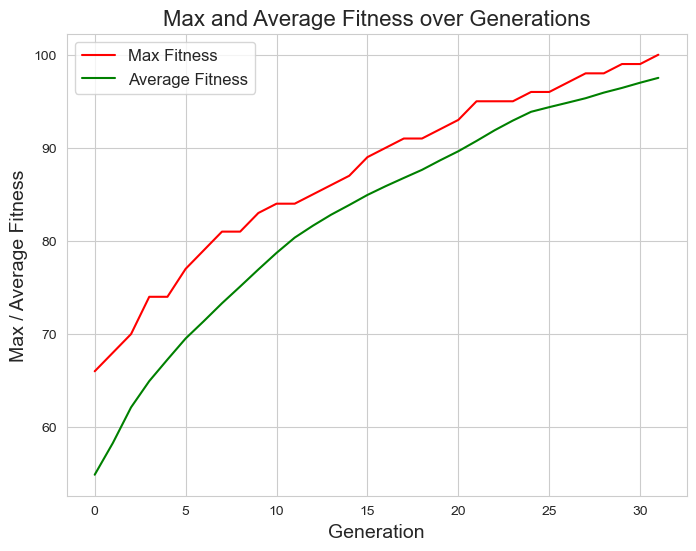

In [15]:
# Estilo de Seaborn
sns.set_style("whitegrid")

# Aumentar el tamaño de la figura
plt.figure(figsize=(8, 6))  # ancho=12 pulgadas, alto=6 pulgadas

# Graficar
plt.plot(maxFitnessValues, color='red', label='Max Fitness')
plt.plot(meanFitnessValues, color='green', label='Average Fitness')

# Etiquetas y título
plt.xlabel('Generation', fontsize=14)
plt.ylabel('Max / Average Fitness', fontsize=14)
plt.title('Max and Average Fitness over Generations', fontsize=16)

# Leyenda
plt.legend(fontsize=12)

# Mostrar
plt.show()


<div style="border: 2px solid #4CAF50; padding: 5px; border-radius: 4px; background-color: #e8f5e9; text-align: center;">
</div>

# **Problema One-Max - Versión usando** *algorithms.eaSimple*

In [16]:
from deap import base
from deap import creator
from deap import tools
from deap import algorithms

import random
import numpy

import matplotlib.pyplot as plt
import seaborn as sns

# problem constants:
ONE_MAX_LENGTH = 100  # length of bit string to be optimized

# Genetic Algorithm constants:
POPULATION_SIZE = 200
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual
MAX_GENERATIONS = 50


# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

toolbox = base.Toolbox()

# create an operator that randomly returns 0 or 1:
toolbox.register("zeroOrOne", random.randint, 0, 1)

# define a single objective, maximizing fitness strategy:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMax)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initRepeat, creator.Individual, toolbox.zeroOrOne, ONE_MAX_LENGTH)

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)


# fitness calculation:
# compute the number of '1's in the individual
def oneMaxFitness(individual):
    return sum(individual),  # return a tuple


toolbox.register("evaluate", oneMaxFitness)

# genetic operators:mutFlipBit

# Tournament selection with tournament size of 3:
toolbox.register("select", tools.selTournament, tournsize=3)

# Single-point crossover:
toolbox.register("mate", tools.cxOnePoint)

# Flip-bit mutation:
# indpb: Independent probability for each attribute to be flipped
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/ONE_MAX_LENGTH)

C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


## Flujo del Algoritmo Genético (Genetic Algorithm Flow)

Este bloque realiza el flujo principal del algoritmo genético utilizando las funciones automatizadas de DEAP:

### 1. **Creación de la población inicial**  
   Se genera la primera población (generación 0) llamando a `populationCreator`, que produce una lista de individuos aleatorios del tamaño definido por `POPULATION_SIZE`.

In [17]:
# create initial population (generation 0):
population = toolbox.populationCreator(n=POPULATION_SIZE)

### 2. **Preparación del objeto de estadísticas**  
   Se construye un objeto `Statistics` que extrae el valor de aptitud (`fitness.values`) de cada individuo.  
   Luego se registran dos funciones para calcular:
   - `max`: el valor máximo de fitness por generación.  
   - `avg`: el valor promedio de fitness por generación.
   - `std`: la desviación estándar del fitness en la población.
   Estas estadísticas serán calculadas automáticamente durante la evolución.

In [18]:
# prepare the statistics object:
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", numpy.max)
stats.register("avg", numpy.mean)
stats.register("std", numpy.std)

### 3. **Ejecución del algoritmo genético completo**  
   Se llama a `algorithms.eaSimple`, una implementación estándar del flujo de un GA en DEAP.  
   Esta función:
   - Realiza selección, cruce y mutación en cada generación.
   - Actualiza el fitness de los individuos.
   - Guarda estadísticas en un registro (`logbook`).
   - Ejecuta el proceso por `MAX_GENERATIONS` generaciones o hasta que termine el flujo definido.  
   El parámetro `verbose=True` hace que se impriman las estadísticas en pantalla durante la ejecución.

In [19]:
# perform the Genetic Algorithm flow:
population, logbook = algorithms.eaSimple(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION, ngen=MAX_GENERATIONS,
                               stats=stats, verbose=True)

gen	nevals	max	avg   	std    
0  	200   	61 	49.695	4.82618
1  	193   	65 	53.575	4.17665
2  	179   	66 	56.855	3.19593
3  	187   	69 	59.42 	3.12147
4  	184   	70 	62.03 	3.12075
5  	188   	75 	64.715	3.14385
6  	176   	75 	67.515	2.89651
7  	184   	77 	70.215	2.63036
8  	180   	81 	72.475	2.76756
9  	174   	82 	74.79 	2.32075
10 	172   	85 	76.685	2.13443
11 	177   	85 	78.46 	2.07085
12 	178   	87 	80.265	2.0772 
13 	178   	87 	81.8  	1.83848
14 	184   	87 	83.15 	1.78816
15 	181   	89 	84.4  	1.62481
16 	185   	89 	85.59 	1.43245
17 	174   	90 	86.755	1.26292
18 	186   	91 	87.715	1.09717
19 	184   	92 	88.495	1.16188
20 	178   	92 	89.275	1.10425
21 	176   	93 	90.04 	1.04805
22 	185   	94 	90.865	1.14314
23 	180   	94 	91.645	1.26845
24 	177   	95 	92.69 	0.961197
25 	191   	95 	93.325	0.830286
26 	169   	95 	93.935	0.775097
27 	184   	96 	94.39 	0.786066
28 	184   	96 	94.84 	0.586856
29 	179   	96 	95.07 	0.644283
30 	183   	97 	95.325	0.692369
31 	180   	97 	95.69 	0.627615
32

### 4. **Extracción de estadísticas finales**  
   Una vez completada la evolución, el `logbook` guarda la historia del GA.  
   Se extraen los valores máximos y promedios de fitness por generación mediante `logbook.select("max", "avg")`, lo que permite graficar o analizar posteriormente el comportamiento del algoritmo.

In [20]:
# Genetic Algorithm is done - extract statistics:
maxFitnessValues, meanFitnessValues, std = logbook.select("max", "avg", "std")

### Visualización de estadísticas del Algoritmo Genético

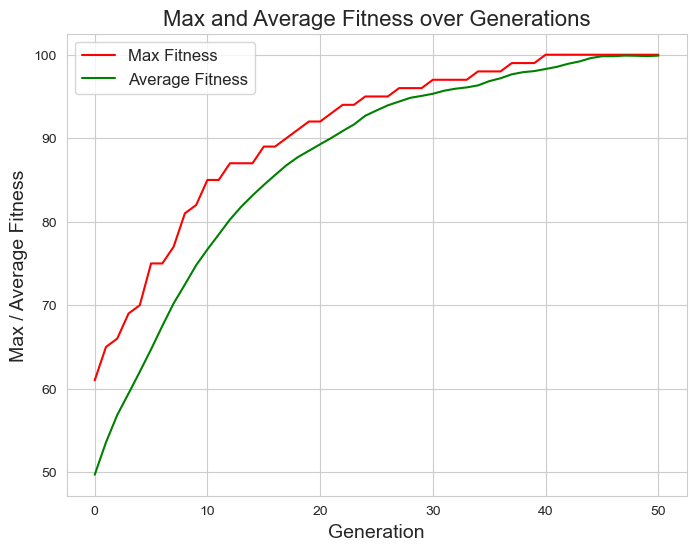

In [21]:
# Estilo de Seaborn
sns.set_style("whitegrid")

# Aumentar el tamaño de la figura
plt.figure(figsize=(8, 6))  # ancho=12 pulgadas, alto=6 pulgadas

# Graficar
plt.plot(maxFitnessValues, color='red', label='Max Fitness')
plt.plot(meanFitnessValues, color='green', label='Average Fitness')

# Etiquetas y título
plt.xlabel('Generation', fontsize=14)
plt.ylabel('Max / Average Fitness', fontsize=14)
plt.title('Max and Average Fitness over Generations', fontsize=16)

# Leyenda
plt.legend(fontsize=12)

# Mostrar
plt.show()

<div style="border: 2px solid #4CAF50; padding: 5px; border-radius: 4px; background-color: #e8f5e9; text-align: center;">
</div>

# Agregando el Salón de la Fama (Hall of Fame)

- Una característica adicional del método `algorithms.eaSimple` incorporado en DEAP es el *hall of fame* (o **hof**, por sus siglas en inglés).
- Implementado en el módulo `tools`, la clase `HallOfFame` permite conservar a los mejores individuos que han existido en la población durante todo el proceso evolutivo, incluso si fueron eliminados posteriormente debido a la selección, el cruce o la mutación.

> El salón de la fama se mantiene ordenado de forma continua, de manera que el primer elemento corresponde al individuo que ha tenido el mejor valor de aptitud observado en toda la evolución.

In [22]:
from deap import base
from deap import creator
from deap import tools
from deap import algorithms

import random
import numpy

import matplotlib.pyplot as plt
import seaborn as sns

# problem constants:
ONE_MAX_LENGTH = 100  # length of bit string to be optimized

# Genetic Algorithm constants:
POPULATION_SIZE = 200
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual
MAX_GENERATIONS = 50
HALL_OF_FAME_SIZE = 10


# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

toolbox = base.Toolbox()

# create an operator that randomly returns 0 or 1:
toolbox.register("zeroOrOne", random.randint, 0, 1)

# define a single objective, maximizing fitness strategy:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMax)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initRepeat, creator.Individual, toolbox.zeroOrOne, ONE_MAX_LENGTH)

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)


# fitness calculation:
# compute the number of '1's in the individual
def oneMaxFitness(individual):
    return sum(individual),  # return a tuple


toolbox.register("evaluate", oneMaxFitness)

# genetic operators:mutFlipBit

# Tournament selection with tournament size of 3:
toolbox.register("select", tools.selTournament, tournsize=3)

# Single-point crossover:
toolbox.register("mate", tools.cxOnePoint)

# Flip-bit mutation:
# indpb: Independent probability for each attribute to be flipped
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/ONE_MAX_LENGTH)


# Genetic Algorithm flow:

# create initial population (generation 0):
population = toolbox.populationCreator(n=POPULATION_SIZE)

# prepare the statistics object:
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", numpy.max)
stats.register("avg", numpy.mean)

### añade Hall of Fame

- Y lo pasa al algoritmo evolutivo.

#### **¿Qué hace el Hall of Fame?**

El *Hall of Fame* conserva los **mejores individuos que han aparecido en cualquier generación**, incluso si desaparecen después por:

- selección  
- cruce  
- mutación  

Esto permite:

- Obtener el **mejor individuo absoluto** de toda la historia.  
- Mantener un registro ordenado de los mejores individuos.  
- Conservar soluciones óptimas que pudieron perderse en generaciones posteriores.  



In [23]:
# define the hall-of-fame object:
hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

In [24]:
# perform the Genetic Algorithm flow with hof feature added:
population, logbook = algorithms.eaSimple(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                              ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

# print Hall of Fame info:
print("Hall of Fame Individuals = ", *hof.items, sep="\n")
print("\nBest Ever Individual = ", hof.items[0])

# extract statistics:
maxFitnessValues, meanFitnessValues = logbook.select("max", "avg")

gen	nevals	max	avg   
0  	200   	61 	49.695
1  	193   	65 	53.575
2  	179   	66 	56.855
3  	187   	69 	59.42 
4  	184   	70 	62.03 
5  	188   	75 	64.715
6  	176   	75 	67.515
7  	184   	77 	70.215
8  	180   	81 	72.475
9  	174   	82 	74.79 
10 	172   	85 	76.685
11 	177   	85 	78.46 
12 	178   	87 	80.265
13 	178   	87 	81.8  
14 	184   	87 	83.15 
15 	181   	89 	84.4  
16 	185   	89 	85.59 
17 	174   	90 	86.755
18 	186   	91 	87.715
19 	184   	92 	88.495
20 	178   	92 	89.275
21 	176   	93 	90.04 
22 	185   	94 	90.865
23 	180   	94 	91.645
24 	177   	95 	92.69 
25 	191   	95 	93.325
26 	169   	95 	93.935
27 	184   	96 	94.39 
28 	184   	96 	94.84 
29 	179   	96 	95.07 
30 	183   	97 	95.325
31 	180   	97 	95.69 
32 	189   	97 	95.93 
33 	177   	97 	96.085
34 	188   	98 	96.325
35 	169   	98 	96.835
36 	182   	98 	97.18 
37 	183   	99 	97.655
38 	182   	99 	97.91 
39 	192   	99 	98.04 
40 	173   	100	98.29 
41 	182   	100	98.55 
42 	176   	100	98.915
43 	188   	100	99.195
44 	192   

### Visualización de estadísticas del Algoritmo Genético

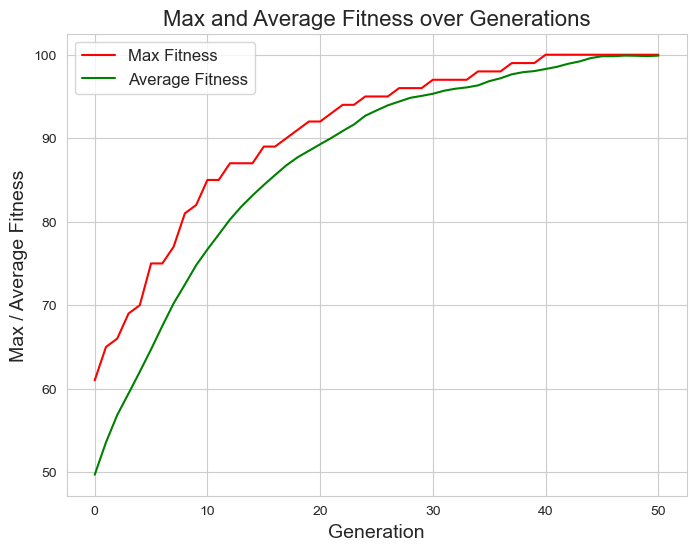

In [25]:
# Estilo de Seaborn
sns.set_style("whitegrid")

# Aumentar el tamaño de la figura
plt.figure(figsize=(8, 6))  # ancho=12 pulgadas, alto=6 pulgadas

# Graficar
plt.plot(maxFitnessValues, color='red', label='Max Fitness')
plt.plot(meanFitnessValues, color='green', label='Average Fitness')

# Etiquetas y título
plt.xlabel('Generation', fontsize=14)
plt.ylabel('Max / Average Fitness', fontsize=14)
plt.title('Max and Average Fitness over Generations', fontsize=16)

# Leyenda
plt.legend(fontsize=12)

# Mostrar
plt.show()

<div style="border: 2px solid #4CAF50; padding: 5px; border-radius: 4px; background-color: #e8f5e9; text-align: center;">
</div>

# **Experimentación con la Configuración del Algoritmo**

## Tamaño de la Población

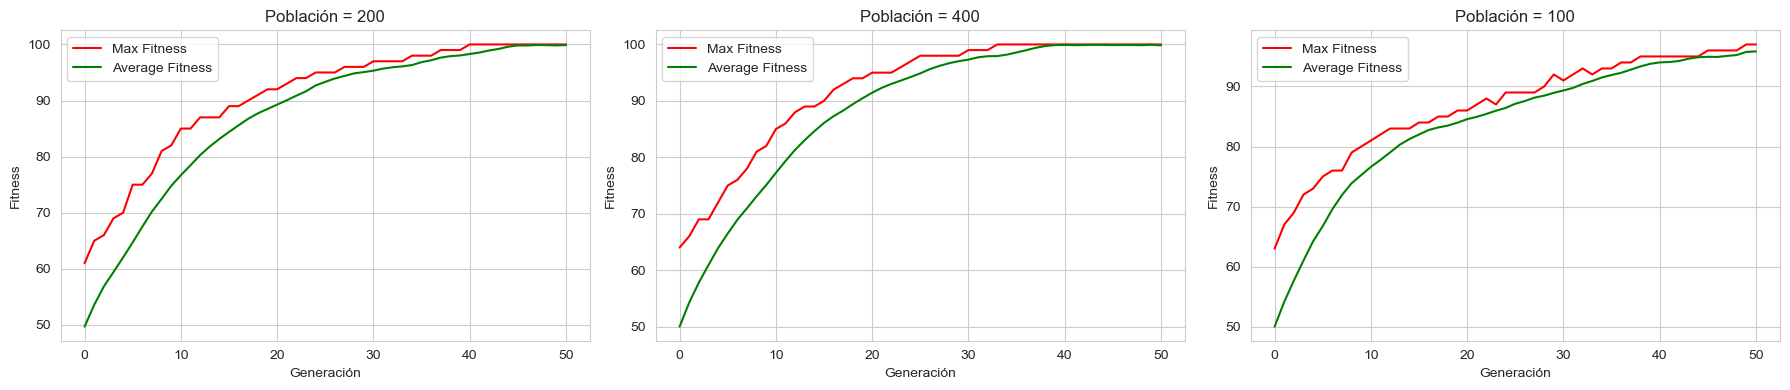

In [26]:
from deap import base
from deap import creator
from deap import tools
from deap import algorithms

import random
import numpy

import matplotlib.pyplot as plt
import seaborn as sns


# ---- PROBLEM CONSTANTS ----
ONE_MAX_LENGTH = 100
P_CROSSOVER = 0.9
P_MUTATION = 0.1
MAX_GENERATIONS = 50
HALL_OF_FAME_SIZE = 10

RANDOM_SEED = 42
random.seed(RANDOM_SEED)


# ---- TOOLBOX INITIALIZATION ----
toolbox = base.Toolbox()
toolbox.register("zeroOrOne", random.randint, 0, 1)

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox.register("individualCreator", tools.initRepeat, creator.Individual,
                 toolbox.zeroOrOne, ONE_MAX_LENGTH)
toolbox.register("populationCreator", tools.initRepeat, list,
                 toolbox.individualCreator)


def oneMaxFitness(individual):
    return sum(individual),
toolbox.register("evaluate", oneMaxFitness)

toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / ONE_MAX_LENGTH)


# ---- FUNCTION TO RUN GENETIC ALGORITHM ----
def run_ga(pop_size):

    population = toolbox.populationCreator(n=pop_size)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", numpy.max)
    stats.register("avg", numpy.mean)

    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    population, logbook = algorithms.eaSimple(
        population, toolbox,
        cxpb=P_CROSSOVER,
        mutpb=P_MUTATION,
        ngen=MAX_GENERATIONS,
        stats=stats,
        halloffame=hof,
        verbose=False  # Para NO imprimir estadísticas en consola
    )

    maxFitnessValues, meanFitnessValues = logbook.select("max", "avg")
    return maxFitnessValues, meanFitnessValues


# ---- RUN GA FOR POPULATIONS 200, 400, 100 ----
pop_sizes = [200, 400, 100]
results = {size: run_ga(size) for size in pop_sizes}


# ---- PLOTTING ----
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 4))  # 1 fila, 3 columnas

for ax, size in zip(axes, pop_sizes):
    maxF, avgF = results[size]
    ax.plot(maxF, color='red', label='Max Fitness')
    ax.plot(avgF, color='green', label='Average Fitness')
    ax.set_title(f"Población = {size}")
    ax.set_xlabel("Generación")
    ax.set_ylabel("Fitness")
    ax.legend()

plt.tight_layout()
plt.show()



## Número de Generaciones

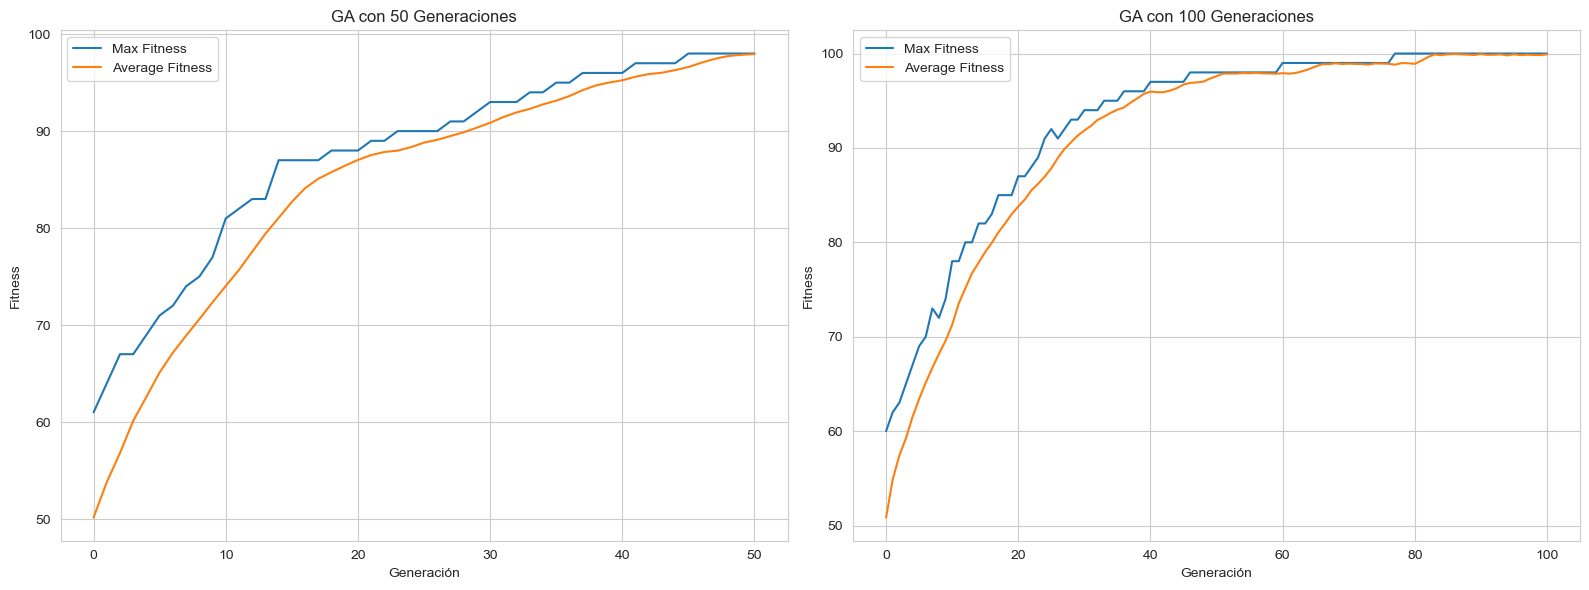

In [27]:
from deap import base
from deap import creator
from deap import tools
from deap import algorithms

import random
import numpy
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================
# Función auxiliar para ejecutar el GA
# ==============================================
def run_ga(MAX_GENERATIONS, POPULATION_SIZE=100):
    ONE_MAX_LENGTH = 100

    toolbox = base.Toolbox()
    toolbox.register("zeroOrOne", random.randint, 0, 1)

    # Evitar errores si ya fue creado antes
    if not hasattr(creator, "FitnessMax"):
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if not hasattr(creator, "Individual"):
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox.register("individualCreator", tools.initRepeat, creator.Individual,
                     toolbox.zeroOrOne, ONE_MAX_LENGTH)

    toolbox.register("populationCreator", tools.initRepeat, list,
                     toolbox.individualCreator)

    def oneMaxFitness(individual):
        return sum(individual),  # regresamos una tupla

    toolbox.register("evaluate", oneMaxFitness)

    toolbox.register("select", tools.selTournament, tournsize=3)
    toolbox.register("mate", tools.cxOnePoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / ONE_MAX_LENGTH)

    population = toolbox.populationCreator(n=POPULATION_SIZE)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", numpy.max)
    stats.register("avg", numpy.mean)

    hof = tools.HallOfFame(10)

    population, logbook = algorithms.eaSimple(
        population, toolbox,
        cxpb=0.9,
        mutpb=0.1,
        ngen=MAX_GENERATIONS,
        stats=stats,
        halloffame=hof,
        verbose=False
    )

    maxFitnessValues, meanFitnessValues = logbook.select("max", "avg")
    return maxFitnessValues, meanFitnessValues


# ==============================================
# Ejecutar los dos experimentos
# ==============================================
random.seed(42)

max50, mean50 = run_ga(MAX_GENERATIONS=50, POPULATION_SIZE=100)
max100, mean100 = run_ga(MAX_GENERATIONS=100, POPULATION_SIZE=100)

# ==============================================
# Graficar dos figuras horizontalmente
# ==============================================
sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))  # ancho grande para poner dos gráficas

# --- Gráfica 1: 50 generaciones ---
plt.subplot(1, 2, 1)
plt.plot(max50, label='Max Fitness')
plt.plot(mean50, label='Average Fitness')
plt.title('GA con 50 Generaciones')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.legend()

# --- Gráfica 2: 100 generaciones ---
plt.subplot(1, 2, 2)
plt.plot(max100, label='Max Fitness')
plt.plot(mean100, label='Average Fitness')
plt.title('GA con 100 Generaciones')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.legend()

plt.tight_layout()
plt.show()


## Cambio del operador de cruce (Crossover)

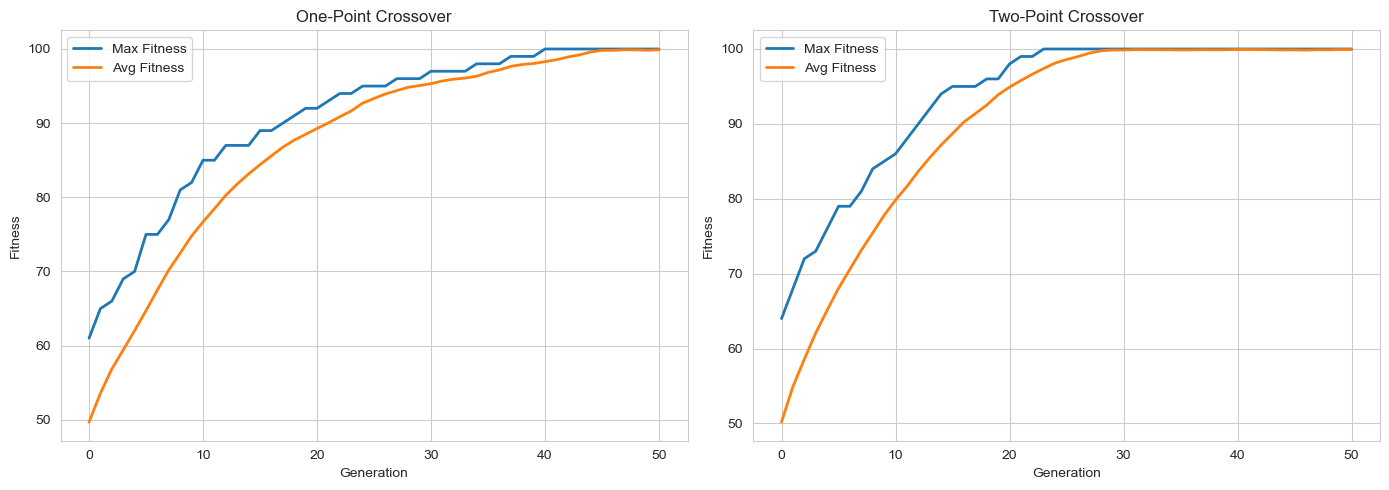

In [28]:
from deap import base, creator, tools, algorithms
import random
import numpy
import matplotlib.pyplot as plt
import seaborn as sns

# Problem constants
ONE_MAX_LENGTH = 100

# GA constants
POPULATION_SIZE = 200
P_CROSSOVER = 0.9
P_MUTATION = 0.1
MAX_GENERATIONS = 50
HALL_OF_FAME_SIZE = 10

# Random seed
RANDOM_SEED = 42
random.seed(RANDOM_SEED)


# -------------------------------------------------------------------------
# Helper function: run GA with a specific crossover operator
# -------------------------------------------------------------------------
def run_ga_with_crossover(crossover_operator):
    
    toolbox = base.Toolbox()

    toolbox.register("zeroOrOne", random.randint, 0, 1)

    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox.register("individualCreator", tools.initRepeat,
                     creator.Individual, toolbox.zeroOrOne, ONE_MAX_LENGTH)

    toolbox.register("populationCreator", tools.initRepeat,
                     list, toolbox.individualCreator)

    def oneMaxFitness(individual):
        return sum(individual),

    toolbox.register("evaluate", oneMaxFitness)

    toolbox.register("select", tools.selTournament, tournsize=3)
    toolbox.register("mate", crossover_operator)
    toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / ONE_MAX_LENGTH)

    population = toolbox.populationCreator(n=POPULATION_SIZE)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", numpy.max)
    stats.register("avg", numpy.mean)

    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    population, logbook = algorithms.eaSimple(
        population, toolbox,
        cxpb=P_CROSSOVER,
        mutpb=P_MUTATION,
        ngen=MAX_GENERATIONS,
        stats=stats,
        halloffame=hof,
        verbose=False
    )

    maxFitnessValues, meanFitnessValues = logbook.select("max", "avg")

    return maxFitnessValues, meanFitnessValues


# -------------------------------------------------------------------------
# Run GA for One-Point and Two-Point crossover
# -------------------------------------------------------------------------
max_one, avg_one = run_ga_with_crossover(tools.cxOnePoint)
max_two, avg_two = run_ga_with_crossover(tools.cxTwoPoint)


# -------------------------------------------------------------------------
# Plot results side by side
# -------------------------------------------------------------------------
sns.set_style("whitegrid")

plt.figure(figsize=(14, 5))

# ---- Left plot: One-Point crossover ----
plt.subplot(1, 2, 1)
plt.plot(max_one, label="Max Fitness", linewidth=2)
plt.plot(avg_one, label="Avg Fitness", linewidth=2)
plt.title("One-Point Crossover")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()

# ---- Right plot: Two-Point crossover ----
plt.subplot(1, 2, 2)
plt.plot(max_two, label="Max Fitness", linewidth=2)
plt.plot(avg_two, label="Avg Fitness", linewidth=2)
plt.title("Two-Point Crossover")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()

plt.tight_layout()
plt.show()


## Cambio del operador de mutación

### P_MUTATION = 0.9

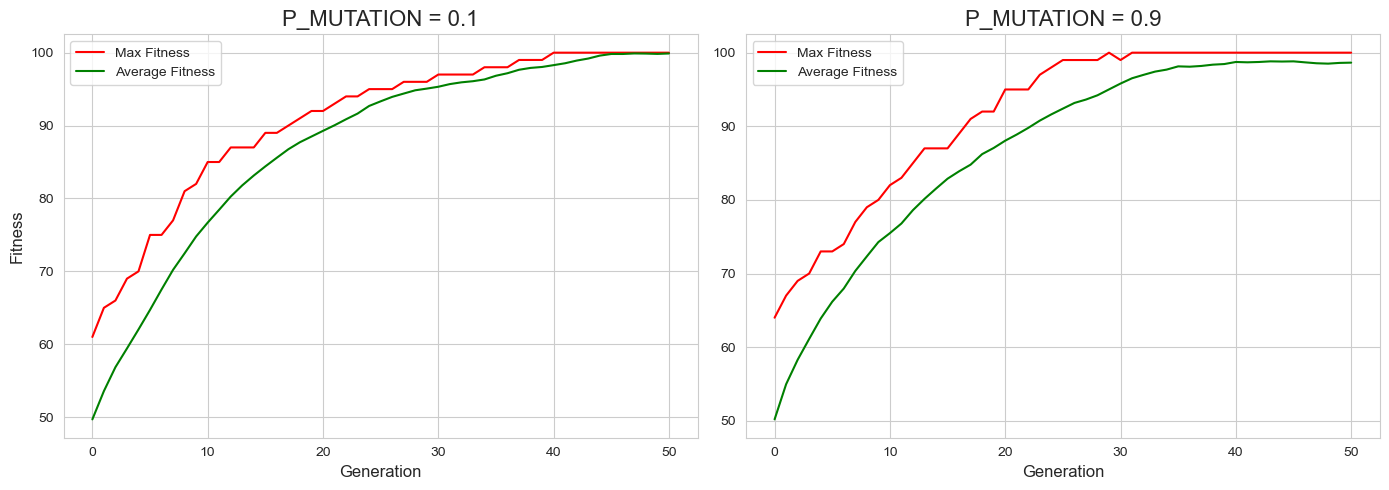

In [29]:
from deap import base
from deap import creator
from deap import tools
from deap import algorithms

import random
import numpy

import matplotlib.pyplot as plt
import seaborn as sns

# problem constants:
ONE_MAX_LENGTH = 100  # length of bit string to be optimized

# Genetic Algorithm constants:
POPULATION_SIZE = 200
P_CROSSOVER = 0.9
MAX_GENERATIONS = 50
HALL_OF_FAME_SIZE = 10

# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# -------------------------------------------------------------------
#   FUNCIÓN: ejecuta el GA y devuelve logbook
# -------------------------------------------------------------------
def run_ga(P_MUTATION):
    toolbox = base.Toolbox()

    toolbox.register("zeroOrOne", random.randint, 0, 1)
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox.register("individualCreator", tools.initRepeat,
                     creator.Individual, toolbox.zeroOrOne, ONE_MAX_LENGTH)
    toolbox.register("populationCreator", tools.initRepeat,
                     list, toolbox.individualCreator)

    def oneMaxFitness(individual):
        return sum(individual),

    toolbox.register("evaluate", oneMaxFitness)
    toolbox.register("select", tools.selTournament, tournsize=3)
    toolbox.register("mate", tools.cxOnePoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/ONE_MAX_LENGTH)

    population = toolbox.populationCreator(n=POPULATION_SIZE)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", numpy.max)
    stats.register("avg", numpy.mean)

    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    population, logbook = algorithms.eaSimple(
        population, toolbox,
        cxpb=P_CROSSOVER,
        mutpb=P_MUTATION,
        ngen=MAX_GENERATIONS,
        stats=stats,
        halloffame=hof,
        verbose=False
    )

    return logbook

# -------------------------------------------------------------------
#   EJECUTAR DOS GA: mutación baja y mutación alta
# -------------------------------------------------------------------
log_low = run_ga(0.1)
log_high = run_ga(0.9)

max_low, avg_low = log_low.select("max", "avg")
max_high, avg_high = log_high.select("max", "avg")

# -------------------------------------------------------------------
#   GRAFICAR DOS FIGURAS LADO A LADO
# -------------------------------------------------------------------
sns.set_style("whitegrid")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# ---- Panel 1: P_MUTATION = 0.1 ----
axs[0].plot(max_low, color='red', label='Max Fitness')
axs[0].plot(avg_low, color='green', label='Average Fitness')
axs[0].set_title("P_MUTATION = 0.1", fontsize=16)
axs[0].set_xlabel("Generation", fontsize=12)
axs[0].set_ylabel("Fitness", fontsize=12)
axs[0].legend()

# ---- Panel 2: P_MUTATION = 0.9 ----
axs[1].plot(max_high, color='red', label='Max Fitness')
axs[1].plot(avg_high, color='green', label='Average Fitness')
axs[1].set_title("P_MUTATION = 0.9", fontsize=16)
axs[1].set_xlabel("Generation", fontsize=12)
axs[1].legend()

plt.tight_layout()
plt.show()


### P_MUTATION = 0.9
### indpb=10.0/ONE_MAX_LENGTH

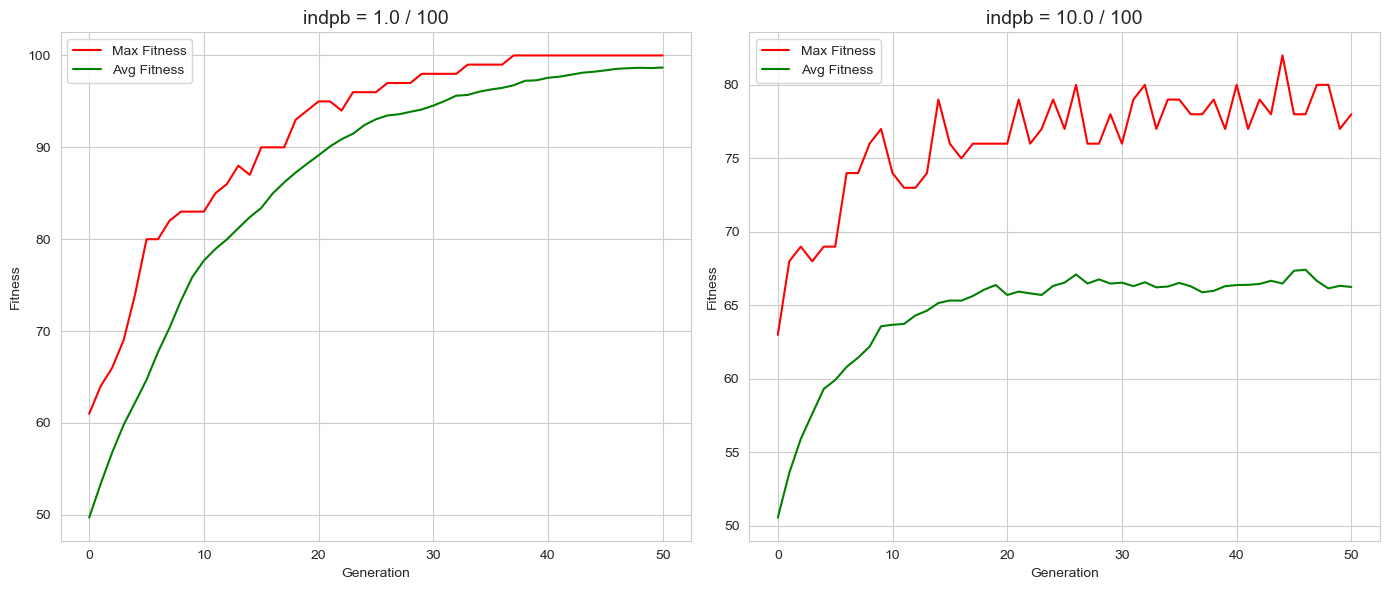

In [30]:
from deap import base
from deap import creator
from deap import tools
from deap import algorithms

import random
import numpy

import matplotlib.pyplot as plt
import seaborn as sns

# problem constants:
ONE_MAX_LENGTH = 100  # length of bit string to be optimized

# Genetic Algorithm constants:
POPULATION_SIZE = 200
P_CROSSOVER = 0.9
P_MUTATION = 0.9
MAX_GENERATIONS = 50
HALL_OF_FAME_SIZE = 10

# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# --- Define GA structure shared by both experiments ---
toolbox = base.Toolbox()
toolbox.register("zeroOrOne", random.randint, 0, 1)
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox.register("individualCreator", tools.initRepeat, creator.Individual,
                 toolbox.zeroOrOne, ONE_MAX_LENGTH)
toolbox.register("populationCreator", tools.initRepeat, list,
                 toolbox.individualCreator)
toolbox.register("evaluate", lambda ind: (sum(ind),))
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", tools.cxOnePoint)

# Statistics
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", numpy.max)
stats.register("avg", numpy.mean)


def run_experiment(indpb_value):
    """Run GA and return max and avg fitness"""
    # Register mutate with specific indpb
    toolbox.register("mutate", tools.mutFlipBit, indpb=indpb_value)

    # Create population
    population = toolbox.populationCreator(n=POPULATION_SIZE)
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    # Run GA
    population, logbook = algorithms.eaSimple(
        population, toolbox,
        cxpb=P_CROSSOVER,
        mutpb=P_MUTATION,
        ngen=MAX_GENERATIONS,
        stats=stats,
        halloffame=hof,
        verbose=False
    )

    # Extract stats
    return logbook.select("max", "avg")


# --- Run both experiments ---
indpb1 = 1.0 / ONE_MAX_LENGTH
indpb10 = 10.0 / ONE_MAX_LENGTH

max1, avg1 = run_experiment(indpb1)
max10, avg10 = run_experiment(indpb10)

# --- Plot two figures side by side ---
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# -------- Plot 1 --------
plt.subplot(1, 2, 1)
plt.plot(max1, label="Max Fitness", color='red')
plt.plot(avg1, label="Avg Fitness", color='green')
plt.title(f"indpb = 1.0 / {ONE_MAX_LENGTH}", fontsize=14)
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()

# -------- Plot 2 --------
plt.subplot(1, 2, 2)
plt.plot(max10, label="Max Fitness", color='red')
plt.plot(avg10, label="Avg Fitness", color='green')
plt.title(f"indpb = 10.0 / {ONE_MAX_LENGTH}", fontsize=14)
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()

plt.tight_layout()
plt.show()


### P_MUTATION = 0.9
### indpb=50.0/ONE_MAX_LENGTH

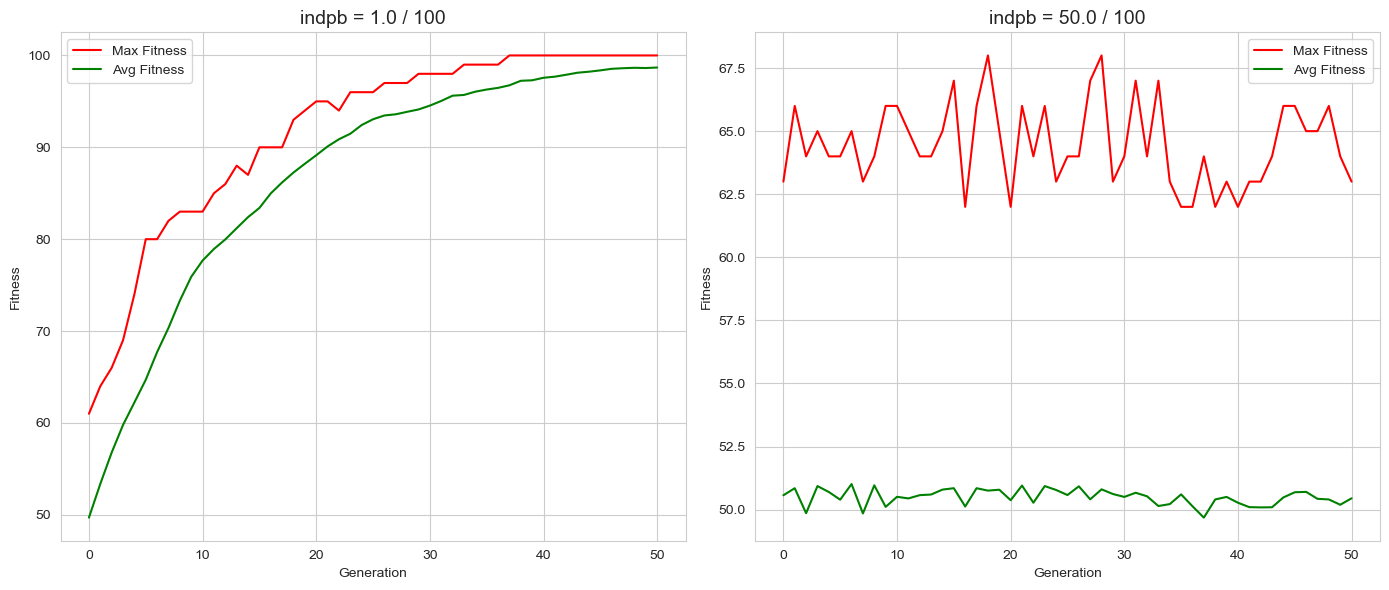

In [31]:
from deap import base
from deap import creator
from deap import tools
from deap import algorithms

import random
import numpy

import matplotlib.pyplot as plt
import seaborn as sns

# problem constants:
ONE_MAX_LENGTH = 100  # length of bit string to be optimized

# Genetic Algorithm constants:
POPULATION_SIZE = 200
P_CROSSOVER = 0.9
P_MUTATION = 0.9
MAX_GENERATIONS = 50
HALL_OF_FAME_SIZE = 10

# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# --- Define GA structure shared by both experiments ---
toolbox = base.Toolbox()
toolbox.register("zeroOrOne", random.randint, 0, 1)
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox.register("individualCreator", tools.initRepeat, creator.Individual,
                 toolbox.zeroOrOne, ONE_MAX_LENGTH)
toolbox.register("populationCreator", tools.initRepeat, list,
                 toolbox.individualCreator)
toolbox.register("evaluate", lambda ind: (sum(ind),))
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", tools.cxOnePoint)

# Statistics
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", numpy.max)
stats.register("avg", numpy.mean)


def run_experiment(indpb_value):
    """Run GA and return max and avg fitness"""
    # Register mutate with specific indpb
    toolbox.register("mutate", tools.mutFlipBit, indpb=indpb_value)

    # Create population
    population = toolbox.populationCreator(n=POPULATION_SIZE)
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    # Run GA
    population, logbook = algorithms.eaSimple(
        population, toolbox,
        cxpb=P_CROSSOVER,
        mutpb=P_MUTATION,
        ngen=MAX_GENERATIONS,
        stats=stats,
        halloffame=hof,
        verbose=False
    )

    # Extract stats
    return logbook.select("max", "avg")


# --- Run both experiments ---
indpb1 = 1.0 / ONE_MAX_LENGTH
indpb10 = 50.0 / ONE_MAX_LENGTH

max1, avg1 = run_experiment(indpb1)
max50, avg50 = run_experiment(indpb10)

# --- Plot two figures side by side ---
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# -------- Plot 1 --------
plt.subplot(1, 2, 1)
plt.plot(max1, label="Max Fitness", color='red')
plt.plot(avg1, label="Avg Fitness", color='green')
plt.title(f"indpb = 1.0 / {ONE_MAX_LENGTH}", fontsize=14)
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()

# -------- Plot 2 --------
plt.subplot(1, 2, 2)
plt.plot(max50, label="Max Fitness", color='red')
plt.plot(avg50, label="Avg Fitness", color='green')
plt.title(f"indpb = 50.0 / {ONE_MAX_LENGTH}", fontsize=14)
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()

plt.tight_layout()
plt.show()


## Cambio del operador de selección

### tournsize=2
### tournsize=100

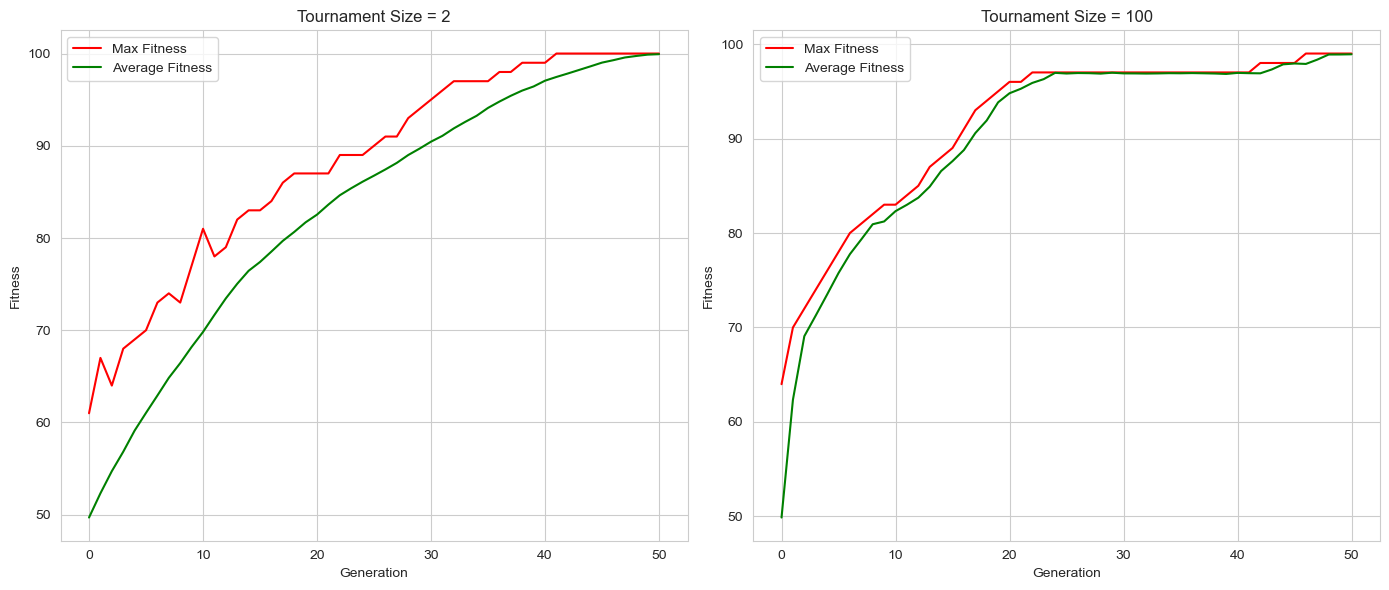

In [32]:
from deap import base
from deap import creator
from deap import tools
from deap import algorithms

import random
import numpy

import matplotlib.pyplot as plt
import seaborn as sns

# problem constants:
ONE_MAX_LENGTH = 100

# GA constants
POPULATION_SIZE = 200
P_CROSSOVER = 0.9
P_MUTATION = 0.1
MAX_GENERATIONS = 50
HALL_OF_FAME_SIZE = 10

# Seed
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# --------------------------------------------------------------------
#   FUNCIÓN PARA EJECUTAR UN EXPERIMENTO CON UN TAMAÑO DE TORNEO DADO
# --------------------------------------------------------------------
def run_experiment(tournsize_value):

    toolbox = base.Toolbox()
    toolbox.register("zeroOrOne", random.randint, 0, 1)

    # Fitness e individuo
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox.register("individualCreator", tools.initRepeat,
                     creator.Individual, toolbox.zeroOrOne, ONE_MAX_LENGTH)

    toolbox.register("populationCreator", tools.initRepeat, list,
                     toolbox.individualCreator)

    # Fitness function
    def oneMaxFitness(individual):
        return sum(individual),

    toolbox.register("evaluate", oneMaxFitness)

    # SELECTION WITH VARIABLE TOURNAMENT SIZE
    toolbox.register("select", tools.selTournament, tournsize=tournsize_value)

    # Crossover
    toolbox.register("mate", tools.cxOnePoint)

    # Mutation
    toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / ONE_MAX_LENGTH)

    # Statistics
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", numpy.max)
    stats.register("avg", numpy.mean)

    # Population and HoF
    population = toolbox.populationCreator(n=POPULATION_SIZE)
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    # Run GA
    population, logbook = algorithms.eaSimple(
        population, toolbox,
        cxpb=P_CROSSOVER,
        mutpb=P_MUTATION,
        ngen=MAX_GENERATIONS,
        stats=stats,
        halloffame=hof,
        verbose=False
    )

    return logbook.select("max", "avg")


# -------------------------------------------------
#   CORRER EXPERIMENTOS tournsize = 2 y tournsize = 100
# -------------------------------------------------
max2, avg2 = run_experiment(2)
max100, avg100 = run_experiment(100)

# -------------------------------------------------
#   PLOTEAR RESULTADOS
# -------------------------------------------------
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# ---- Plot 1: tournsize = 2 ----
plt.subplot(1, 2, 1)
plt.plot(max2, color='red', label="Max Fitness")
plt.plot(avg2, color='green', label="Average Fitness")
plt.title("Tournament Size = 2")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()

# ---- Plot 2: tournsize = 100 ----
plt.subplot(1, 2, 2)
plt.plot(max100, color='red', label="Max Fitness")
plt.plot(avg100, color='green', label="Average Fitness")
plt.title("Tournament Size = 100")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()

plt.tight_layout()
plt.show()


### tournsize=100

### P_MUTATION = 0.01 y 0.001

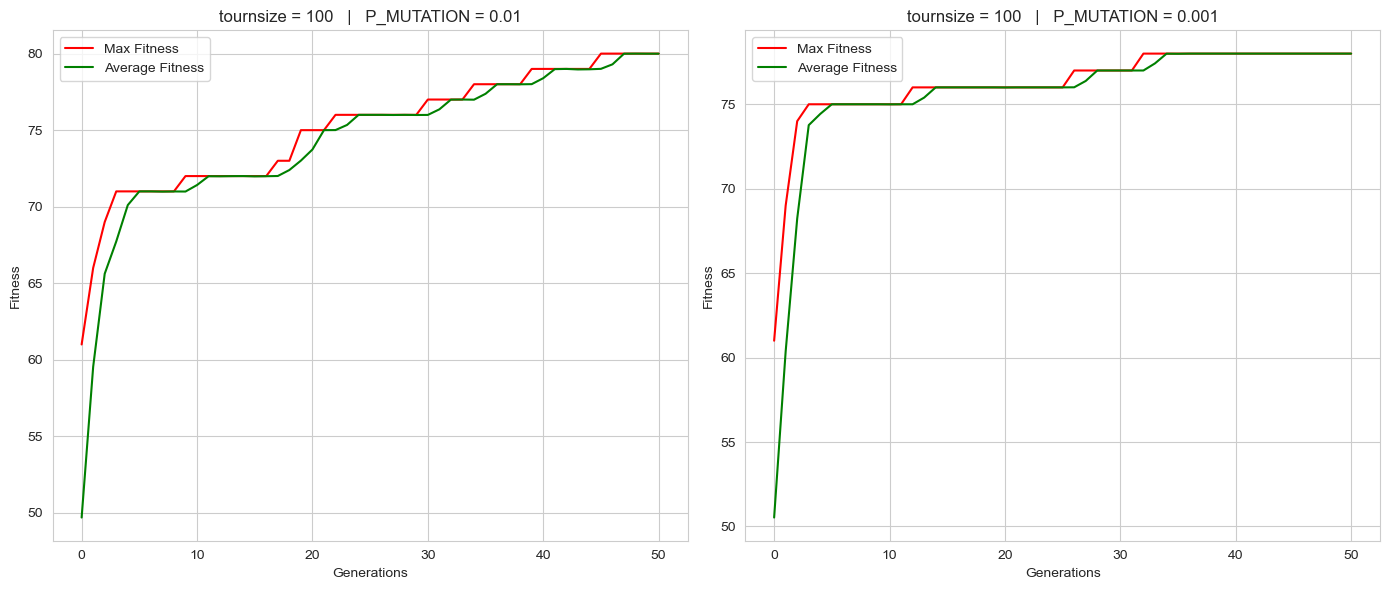

In [33]:
from deap import base
from deap import creator
from deap import tools
from deap import algorithms

import random
import numpy

import matplotlib.pyplot as plt
import seaborn as sns

# problem constants:
ONE_MAX_LENGTH = 100  # length of bit string to be optimized
POPULATION_SIZE = 200
P_CROSSOVER = 0.9
MAX_GENERATIONS = 50
HALL_OF_FAME_SIZE = 10

# Seed
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# --------------------------------------------------------
#   FUNCIÓN PARA EJECUTAR UN EXPERIMENTO CON P_MUTATION
# --------------------------------------------------------
def run_experiment(P_MUT):

    toolbox = base.Toolbox()
    toolbox.register("zeroOrOne", random.randint, 0, 1)

    # Crear tipos de Fitness e Individual
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox.register("individualCreator", tools.initRepeat,
                     creator.Individual, toolbox.zeroOrOne, ONE_MAX_LENGTH)
    toolbox.register("populationCreator", tools.initRepeat,
                     list, toolbox.individualCreator)

    # Fitness
    def oneMaxFitness(individual):
        return sum(individual),

    toolbox.register("evaluate", oneMaxFitness)

    # Selection with tournsize = 100
    toolbox.register("select", tools.selTournament, tournsize=100)

    toolbox.register("mate", tools.cxOnePoint)

    # Mutation
    toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / ONE_MAX_LENGTH)

    # Stats
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", numpy.max)
    stats.register("avg", numpy.mean)

    # Population
    population = toolbox.populationCreator(n=POPULATION_SIZE)
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    # Run the GA
    population, logbook = algorithms.eaSimple(
        population, toolbox,
        cxpb=P_CROSSOVER,
        mutpb=P_MUT,
        ngen=MAX_GENERATIONS,
        stats=stats,
        halloffame=hof,
        verbose=False
    )

    return logbook.select("max", "avg")


# --------------------------------------------------------
#   EXPERIMENTOS: MUTATION RATE 0.01 y 0.001
# --------------------------------------------------------
max_001, avg_001 = run_experiment(0.01)
max_0001, avg_0001 = run_experiment(0.001)

# --------------------------------------------------------
#   PLOTEAR RESULTADOS
# --------------------------------------------------------
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# ---- Gráfica 1: P_MUTATION = 0.01 ----
plt.subplot(1, 2, 1)
plt.plot(max_001, color='red', label='Max Fitness')
plt.plot(avg_001, color='green', label='Average Fitness')
plt.title("tournsize = 100   |   P_MUTATION = 0.01")
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.legend()

# ---- Gráfica 2: P_MUTATION = 0.001 ----
plt.subplot(1, 2, 2)
plt.plot(max_0001, color='red', label='Max Fitness')
plt.plot(avg_0001, color='green', label='Average Fitness')
plt.title("tournsize = 100   |   P_MUTATION = 0.001")
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.legend()

plt.tight_layout()
plt.show()


### Selección por Ruleta

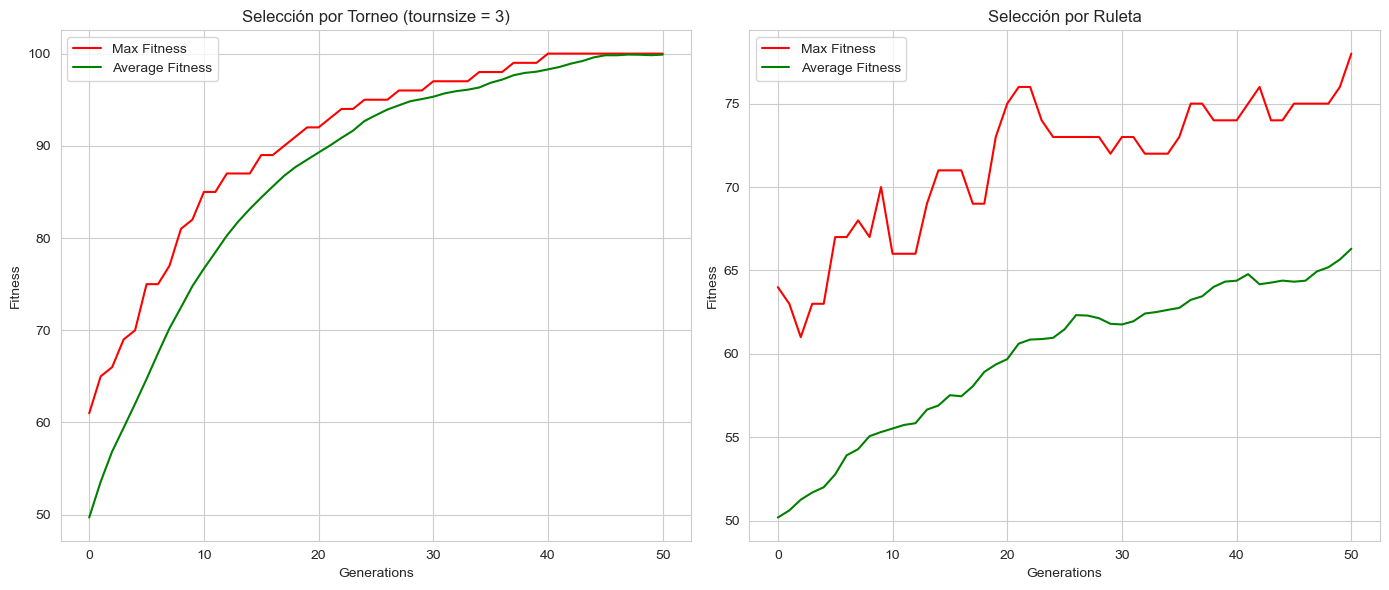

In [34]:
from deap import base
from deap import creator
from deap import tools
from deap import algorithms

import random
import numpy

import matplotlib.pyplot as plt
import seaborn as sns

# Problem constants
ONE_MAX_LENGTH = 100
POPULATION_SIZE = 200
P_CROSSOVER = 0.9
P_MUTATION = 0.1
MAX_GENERATIONS = 50
HALL_OF_FAME_SIZE = 10

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# ----------------------------------------------------------
# FUNCIÓN PARA EJECUTAR EL ALGORITMO CON UN TIPO DE SELECCIÓN
# ----------------------------------------------------------
def run_ga(selection_operator):

    toolbox = base.Toolbox()

    toolbox.register("zeroOrOne", random.randint, 0, 1)

    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox.register("individualCreator", tools.initRepeat,
                     creator.Individual, toolbox.zeroOrOne, ONE_MAX_LENGTH)
    toolbox.register("populationCreator", tools.initRepeat,
                     list, toolbox.individualCreator)

    def oneMaxFitness(individual):
        return sum(individual),

    toolbox.register("evaluate", oneMaxFitness)

    # Selección (RUEDA O TORNEO según el parámetro)
    toolbox.register("select", selection_operator)

    toolbox.register("mate", tools.cxOnePoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / ONE_MAX_LENGTH)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", numpy.max)
    stats.register("avg", numpy.mean)

    population = toolbox.populationCreator(n=POPULATION_SIZE)
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    population, logbook = algorithms.eaSimple(
        population, toolbox,
        cxpb=P_CROSSOVER,
        mutpb=P_MUTATION,
        ngen=MAX_GENERATIONS,
        stats=stats,
        halloffame=hof,
        verbose=False
    )

    return logbook.select("max", "avg")


# ----------------------------------------------------------
# CORRER EXPERIMENTOS
# ----------------------------------------------------------

# Torneo (tournsize=3 como el código original)
def tournament_selection(population, k):
    return tools.selTournament(population, k, tournsize=3)

max_tour, avg_tour = run_ga(tournament_selection)

# Ruleta
max_roulette, avg_roulette = run_ga(tools.selRoulette)


# ----------------------------------------------------------
# GRAFICAR RESULTADOS LADO A LADO
# ----------------------------------------------------------

sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# ---- Gráfica torneo ----
plt.subplot(1, 2, 1)
plt.plot(max_tour, color='red', label='Max Fitness')
plt.plot(avg_tour, color='green', label='Average Fitness')
plt.title("Selección por Torneo (tournsize = 3)")
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.legend()

# ---- Gráfica ruleta ----
plt.subplot(1, 2, 2)
plt.plot(max_roulette, color='red', label='Max Fitness')
plt.plot(avg_roulette, color='green', label='Average Fitness')
plt.title("Selección por Ruleta")
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.legend()

plt.tight_layout()
plt.show()


### Selección por Ruleta Sin y Con Elitismo

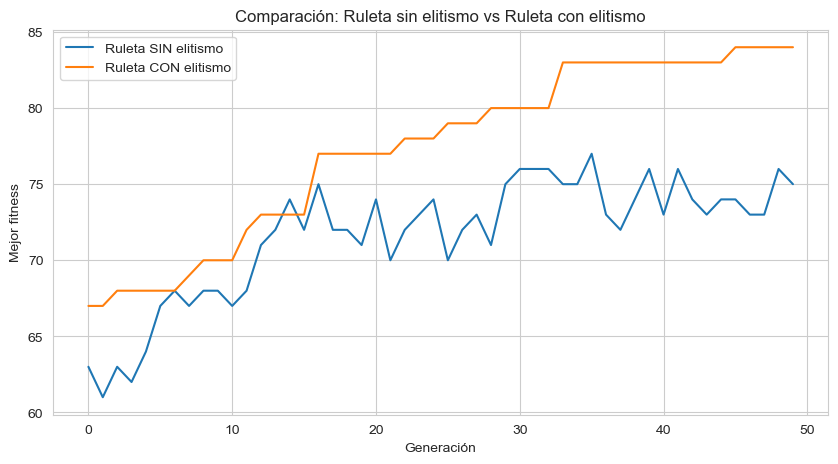

In [35]:
from deap import base, creator, tools
import random
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
#          CONFIGURACIÓN GENERAL DEL PROBLEMA
# =====================================================
ONE_MAX_LENGTH = 100
POPULATION_SIZE = 200
P_CROSSOVER = 0.9
P_MUTATION = 0.1
ELITE_SIZE = 2
GENERATIONS = 50

# Crear tipo de individuo y fitness
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, ONE_MAX_LENGTH)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Función de evaluación
def evalOneMax(individual):
    return (sum(individual),)

toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / ONE_MAX_LENGTH)
toolbox.register("evaluate", evalOneMax)


# =====================================================
#     GA 1: Selección por RULETA (SIN ELITISMO)
# =====================================================
def run_ga_roulette_no_elite():
    toolbox.register("select", tools.selRoulette)

    pop = toolbox.population(n=POPULATION_SIZE)

    # Evaluación inicial
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)

    best_per_gen = []

    for g in range(GENERATIONS):

        # Selección normal (sin elitismo)
        offspring = toolbox.select(pop, POPULATION_SIZE)
        offspring = list(map(toolbox.clone, offspring))

        # Cruce
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < P_CROSSOVER:
                toolbox.mate(c1, c2)
                del c1.fitness.values
                del c2.fitness.values

        # Mutación
        for m in offspring:
            if random.random() < P_MUTATION:
                toolbox.mutate(m)
                del m.fitness.values

        # Evaluación
        invalid = [ind for ind in offspring if not ind.fitness.valid]
        for ind in invalid:
            ind.fitness.values = toolbox.evaluate(ind)

        pop = offspring

        best_per_gen.append(max(ind.fitness.values[0] for ind in pop))

    return best_per_gen


# =====================================================
#      GA 2: Selección por RULETA (CON ELITISMO)
# =====================================================
def run_ga_roulette_elitism():
    toolbox.register("select", tools.selRoulette)

    pop = toolbox.population(n=POPULATION_SIZE)

    # Evaluación inicial
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)

    best_per_gen = []

    for g in range(GENERATIONS):

        # Guardar los mejores (ELITISMO)
        elites = tools.selBest(pop, ELITE_SIZE)
        elites = list(map(toolbox.clone, elites))

        # Selección del resto
        offspring = toolbox.select(pop, POPULATION_SIZE - ELITE_SIZE)
        offspring = list(map(toolbox.clone, offspring))

        # Cruce
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < P_CROSSOVER:
                toolbox.mate(c1, c2)
                del c1.fitness.values
                del c2.fitness.values

        # Mutación
        for m in offspring:
            if random.random() < P_MUTATION:
                toolbox.mutate(m)
                del m.fitness.values

        # Evaluación
        invalid = [ind for ind in offspring if not ind.fitness.valid]
        for ind in invalid:
            ind.fitness.values = toolbox.evaluate(ind)

        # Nueva población
        pop = elites + offspring

        best_per_gen.append(max(ind.fitness.values[0] for ind in pop))

    return best_per_gen


# =====================================================
#              EJECUCIÓN Y GRÁFICA
# =====================================================
best_roulette_no_elite = run_ga_roulette_no_elite()
best_roulette_elite = run_ga_roulette_elitism()

plt.figure(figsize=(10,5))
plt.plot(best_roulette_no_elite, label="Ruleta SIN elitismo")
plt.plot(best_roulette_elite, label="Ruleta CON elitismo")
plt.xlabel("Generación")
plt.ylabel("Mejor fitness")
plt.title("Comparación: Ruleta sin elitismo vs Ruleta con elitismo")
plt.legend()
plt.grid(True)
plt.show()


<div style="border: 2px solid #4CAF50; padding: 5px; border-radius: 4px; background-color: #e8f5e9; text-align: center;">
</div>

# **Problemas de búsqueda y optimización combinatoria** 
## (Search problems and combinatorial optimization)


## **El problema de la mochila** (knapsack problem)

In [36]:
from deap import base
from deap import creator
from deap import tools
from deap import algorithms

import random
import numpy

import matplotlib.pyplot as plt
import seaborn as sns

from Codigo_AG_py import knapsack



### Se crea una instancia del problema de la mochila

In [37]:
# create the knapsack problem instance to be used:
knapsack = knapsack.Knapsack01Problem()

In [38]:
# Genetic Algorithm constants:
POPULATION_SIZE = 50
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual
MAX_GENERATIONS = 50
HALL_OF_FAME_SIZE = 1


# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

toolbox = base.Toolbox()

# create an operator that randomly returns 0 or 1:
toolbox.register("zeroOrOne", random.randint, 0, 1)

# define a single objective, maximizing fitness strategy:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMax)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initRepeat, creator.Individual, toolbox.zeroOrOne, len(knapsack))

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)

### Se indica al algoritmo genético que utilice el método getValue() de dicha instancia para la evaluación de la aptitud.

In [39]:
# fitness calculation
def knapsackValue(individual):
    return knapsack.getValue(individual),  # return a tuple


toolbox.register("evaluate", knapsackValue)

### Los operadores genéticos utilizados son compatibles con el cromosoma representado como una lista binaria.

In [40]:
# genetic operators:mutFlipBit

# Tournament selection with tournament size of 3:
toolbox.register("select", tools.selTournament, tournsize=3)

# Single-point crossover:
toolbox.register("mate", tools.cxTwoPoint)

# Flip-bit mutation:
# indpb: Independent probability for each attribute to be flipped
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/len(knapsack))

In [41]:
# Genetic Algorithm flow:

# create initial population (generation 0):
population = toolbox.populationCreator(n=POPULATION_SIZE)

# prepare the statistics object:
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", numpy.max)
stats.register("avg", numpy.mean)

# define the hall-of-fame object:
hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

# perform the Genetic Algorithm flow with hof feature added:
population, logbook = algorithms.eaSimple(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                          ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

gen	nevals	max	avg   
0  	50    	805	595.86
1  	50    	860	704.66
2  	48    	867	750.42
3  	46    	905	793.74
4  	48    	945	826.8 
5  	46    	955	858.18
6  	42    	1000	897.02
7  	44    	1002	916   
8  	46    	1030	952.2 
9  	45    	1030	974.14
10 	50    	1030	985.88
11 	48    	1030	998.9 
12 	45    	1030	1003.7
13 	47    	1030	1023.3
14 	45    	1030	1018.9
15 	46    	1030	1021.6
16 	47    	1030	1022.1
17 	48    	1030	1026.7
18 	46    	1030	1020  
19 	43    	1030	1018.34
20 	46    	1030	1024.9 
21 	46    	1030	1016.9 
22 	45    	1030	1022.8 
23 	46    	1030	1027.7 
24 	44    	1030	1021.1 
25 	49    	1030	1025.7 
26 	44    	1030	1015.6 
27 	42    	1030	1017.1 
28 	44    	1030	1017.1 
29 	43    	1030	1023.24
30 	50    	1030	1025.6 
31 	46    	1030	1025.5 
32 	48    	1030	1027.5 
33 	46    	1030	1030   
34 	47    	1030	1018.74
35 	47    	1030	1023.2 
36 	36    	1030	1024.1 
37 	48    	1030	1016.1 
38 	45    	1030	1022.6 
39 	42    	1030	1018.7 
40 	47    	1030	1022.94
41 	46    	1030	102

### Se puede utilizar el método printItems() para mostrar de forma legible la mejor solución encontrada.

In [42]:
# print best solution found:
best = hof.items[0]
print("\n-- Best Ever Individual = ", best)
print("-- Best Ever Fitness = ", best.fitness.values[0])

print("-- Knapsack Items = ")
knapsack.printItems(best)


-- Best Ever Individual =  [1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1]
-- Best Ever Fitness =  1030.0
-- Knapsack Items = 
- Adding map: weight = 9, value = 150, accumulated weight = 9, accumulated value = 150
- Adding compass: weight = 13, value = 35, accumulated weight = 22, accumulated value = 185
- Adding water: weight = 153, value = 200, accumulated weight = 175, accumulated value = 385
- Adding sandwich: weight = 50, value = 160, accumulated weight = 225, accumulated value = 545
- Adding glucose: weight = 15, value = 60, accumulated weight = 240, accumulated value = 605
- Adding banana: weight = 27, value = 60, accumulated weight = 267, accumulated value = 665
- Adding suntan cream: weight = 11, value = 70, accumulated weight = 278, accumulated value = 735
- Adding waterproof trousers: weight = 42, value = 70, accumulated weight = 320, accumulated value = 805
- Adding waterproof overclothes: weight = 43, value = 75, accumulated weight = 363, accumulated va

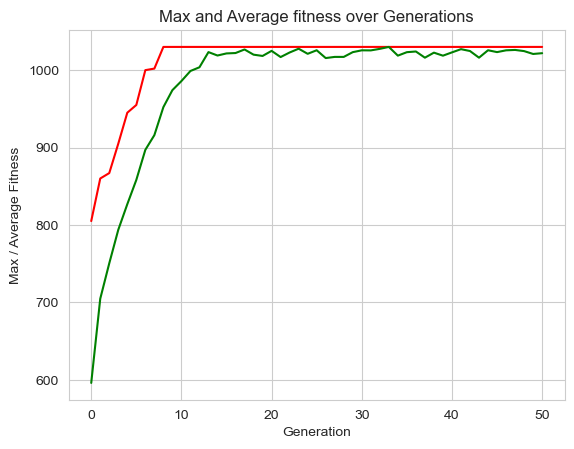

In [43]:
# extract statistics:
maxFitnessValues, meanFitnessValues = logbook.select("max", "avg")

# plot statistics:
sns.set_style("whitegrid")
plt.plot(maxFitnessValues, color='red')
plt.plot(meanFitnessValues, color='green')
plt.xlabel('Generation')
plt.ylabel('Max / Average Fitness')
plt.title('Max and Average fitness over Generations')
plt.show()

## **El problema del viajero** (Travelling Salesman Problem - TSP)

In [44]:
from deap import base
from deap import creator
from deap import tools
from deap import algorithms

import random
import array

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from Codigo_AG_py import  tsp

# set the random seed for repeatable results
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

### El programa inicia creando una instancia del problema *bayg29* de la siguiente manera:


In [45]:
# create the desired traveling salesman problem instace:
TSP_NAME = "bayg29"  # name of problem
tsp = tsp.TravelingSalesmanProblem(TSP_NAME)

In [46]:
# Genetic Algorithm constants:
POPULATION_SIZE = 300
MAX_GENERATIONS = 200
HALL_OF_FAME_SIZE = 1
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual

toolbox = base.Toolbox()

### A continuación, se debe definir la estrategia de aptitud. 

- En este caso, se desea minimizar la distancia, lo que se traduce en una clase de aptitud de un solo objetivo de minimización, definida mediante un único peso negativo:


In [47]:
# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

### La representación cromosómica elegida corresponde a una lista de enteros desde 0 hasta *n−1*, 
- donde *n* es el número de ciudades;
- cada entero representa el índice de una ciudad.  


La clase **Individual** se crea primero, extendiendo un arreglo de enteros y añadiéndole la clase **FitnessMin**.


In [48]:
# create the Individual class based on list of integers:
creator.create("Individual", array.array, typecode='i', fitness=creator.FitnessMin)

El operador **randomOrder** se registra a continuación para proporcionar los resultados de la invocación `random.sample()` sobre un rango definido por la longitud del problema TSP (el número de ciudades, o *n*). 

Esto produce una lista aleatoria de índices entre 0 y *n−1*.


In [49]:
# create an operator that generates randomly shuffled indices:
toolbox.register("randomOrder", random.sample, range(len(tsp)), len(tsp))

El operador **IndividualCreator** se crea a continuación. 

Cuando es invocado, este operador llama internamente a **randomOrder** y recorre sus resultados para crear un cromosoma válido compuesto por los índices de las ciudades.


In [50]:
# create the individual creation operator to fill up an Individual instance with shuffled indices:
toolbox.register("individualCreator", tools.initIterate, creator.Individual, toolbox.randomOrder)

Se crea el operador **populationCreator**, encargado de producir una lista de individuos utilizando el operador **IndividualCreator**.


In [51]:
# create the population creation operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)

Una vez implementado el cromosoma, es momento de definir la función de evaluación de la aptitud. 

Esta tarea es realizada por la función **tspDistance()**, que utiliza directamente el método **getTotalDistance()** de la clase **TravelingSalesmanProblem**.


In [52]:
# fitness calculation - compute the total distance of the list of cities represented by indices:
def tpsDistance(individual):
    return tsp.getTotalDistance(individual),  # return a tuple

toolbox.register("evaluate", tpsDistance)

A continuación, se deben definir los operadores genéticos. 

Para el operador de selección, se puede utilizar la **selección por torneo** con un tamaño de torneo de 3, tal como se hizo en casos anteriores.


In [53]:
# Genetic operators:
toolbox.register("select", tools.selTournament, tournsize=3)

Sin embargo, antes de seleccionar los operadores de cruce y mutación, se debe recordar que el cromosoma utilizado no es simplemente una lista de enteros, sino una lista de índices que representan el orden de las ciudades. 

Por lo tanto, no se puede mezclar partes de dos listas ni cambiar un índice de forma arbitraria. 

En su lugar, se deben usar operadores especializados diseñados para generar listas válidas de índices. 

Aquí se utiliza la implementación del operador **ordered crossover** en DEAP.


In [54]:
toolbox.register("mate", tools.cxOrdered)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=1.0/len(tsp))

Finalmente, es momento de ejecutar el flujo del algoritmo genético. 

Aquí se utiliza el algoritmo **eaSimple** incorporado en DEAP, junto con los objetos por defecto de **stats** y **halloffame** para proporcionar información que luego se puede utilizar para mostrar resultados.


In [55]:
# Genetic Algorithm flow:

# create initial population (generation 0):
population = toolbox.populationCreator(n=POPULATION_SIZE)

# prepare the statistics object:
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", np.min)
stats.register("avg", np.mean)

# define the hall-of-fame object:
hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

# perform the Genetic Algorithm flow with hof feature added:
population, logbook = algorithms.eaSimple(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                          ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

gen	nevals	min          	avg            
0  	300   	21103.2734375	26457.017578125
1  	279   	19562.376953125	25128.8828125  
2  	275   	19456.48828125 	24267.263671875
3  	279   	19760.888671875	23591.994140625
4  	278   	19406.35546875 	22963.548828125
5  	276   	19105.15625    	22480.697265625
6  	281   	17802.38671875 	22129.904296875
7  	279   	18160.24609375 	21581.50390625 
8  	274   	17691.30859375 	21253.615234375
9  	277   	16011.8740234375	20877.779296875
10 	268   	16011.8740234375	20597.896484375
11 	279   	15878.7939453125	20413.21875    
12 	269   	14589.10546875  	20188.173828125
13 	272   	14589.10546875  	19987.828125   
14 	281   	15182.85546875  	19910.3984375  
15 	276   	15836.2041015625	19437.013671875
16 	276   	15687.41796875  	19117.20703125 
17 	282   	15426.4658203125	19039.388671875
18 	282   	14905.2275390625	18696.6796875  
19 	269   	15020.447265625 	18614.884765625
20 	275   	13346.267578125 	18424.017578125
21 	276   	14711.4365234375	18330.125      
22

In [56]:
# print best individual info:
best = hof.items[0]
print("\n-- Best Ever Individual = ", best)
print("-- Best Ever Fitness = ", best.fitness.values[0])


-- Best Ever Individual =  Individual('i', [0, 27, 11, 5, 20, 4, 8, 25, 2, 28, 1, 19, 9, 3, 14, 17, 13, 16, 21, 10, 18, 12, 23, 7, 26, 22, 6, 24, 15])
-- Best Ever Fitness =  9549.985


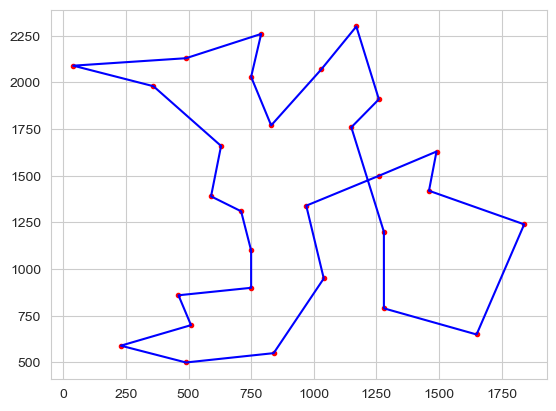

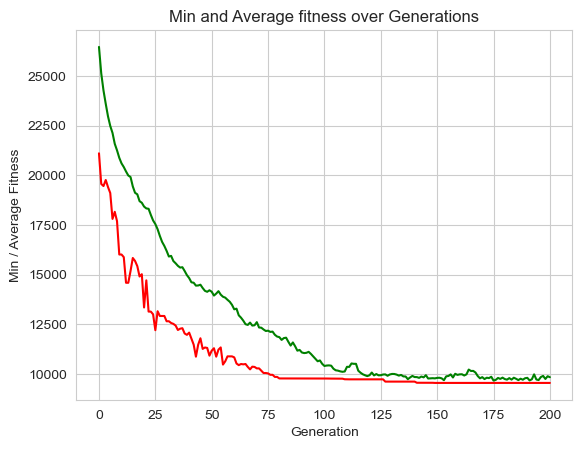

In [57]:
# plot best solution:
plt.figure(1)
tsp.plotData(best)

# plot statistics:
minFitnessValues, meanFitnessValues = logbook.select("min", "avg")
plt.figure(2)
sns.set_style("whitegrid")
plt.plot(minFitnessValues, color='red')
plt.plot(meanFitnessValues, color='green')
plt.xlabel('Generation')
plt.ylabel('Min / Average Fitness')
plt.title('Min and Average fitness over Generations')

# show both plots:
plt.show()

## El problema del viajante mejorado con **elitismo** combinado con una **exploración mejorada**

In [58]:
from deap import base
from deap import creator
from deap import tools

import random
import array

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from Codigo_AG_py import tsp
from Codigo_AG_py import elitism

# set the random seed for repeatable results
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# create the desired traveling salesman problem instace:
TSP_NAME = "bayg29"  # name of problem
tsp = tsp.TravelingSalesmanProblem(TSP_NAME)

# Genetic Algorithm constants:
POPULATION_SIZE = 300
MAX_GENERATIONS = 200
HALL_OF_FAME_SIZE = 30
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual

toolbox = base.Toolbox()

# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

# create the Individual class based on list of integers:
creator.create("Individual", array.array, typecode='i', fitness=creator.FitnessMin)

# create an operator that generates randomly shuffled indices:
toolbox.register("randomOrder", random.sample, range(len(tsp)), len(tsp))

# create the individual creation operator to fill up an Individual instance with shuffled indices:
toolbox.register("individualCreator", tools.initIterate, creator.Individual, toolbox.randomOrder)

# create the population creation operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)


# fitness calculation - compute the total distance of the list of cities represented by indices:
def tpsDistance(individual):
    return tsp.getTotalDistance(individual),  # return a tuple


toolbox.register("evaluate", tpsDistance)


# Genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxOrdered)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=1.0/len(tsp))


# Genetic Algorithm flow:

# create initial population (generation 0):
population = toolbox.populationCreator(n=POPULATION_SIZE)

# prepare the statistics object:
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", np.min)
stats.register("avg", np.mean)

# define the hall-of-fame object:
hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

# perform the Genetic Algorithm flow with hof feature added:
population, logbook = elitism.eaSimpleWithElitism(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                              ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

C:\Users\Flavio\anaconda3\envs\TIA_Entorno\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	min          	avg            
0  	300   	21103.2734375	26457.017578125
1  	252   	19726.44140625	25210.93359375 
2  	249   	18977.08203125	24364.2578125  
3  	257   	17868.193359375	23514.673828125
4  	237   	17585.28125    	22929.759765625
5  	247   	17585.28125    	22350.58203125 
6  	247   	17585.28125    	21831.3828125  
7  	249   	17012.32421875 	21442.607421875
8  	238   	17012.32421875 	20999.689453125
9  	249   	16856.345703125	20513.244140625
10 	249   	16766.4296875  	20235.38671875 
11 	249   	16165.7060546875	19852.787109375
12 	244   	14934.013671875 	19588.443359375
13 	242   	14934.013671875 	19454.267578125
14 	252   	14934.013671875 	19412.607421875
15 	245   	14757.48828125  	19286.609375   
16 	242   	14757.48828125  	19057.173828125
17 	253   	14757.48828125  	18846.88671875 
18 	246   	14757.48828125  	18782.693359375
19 	240   	14607.0322265625	18293.671875   
20 	249   	14607.0322265625	17740.181640625
21 	248   	14227.708984375 	17786.08984375 
22 	23

In [59]:
# print best individual info:
best = hof.items[0]
print("\-- Best Ever Individual = ", best)
print("-- Best Ever Fitness = ", best.fitness.values[0])

\-- Best Ever Individual =  Individual('i', [0, 23, 12, 15, 26, 7, 22, 6, 24, 18, 10, 21, 16, 13, 17, 14, 3, 9, 19, 1, 20, 4, 28, 2, 25, 8, 11, 5, 27])
-- Best Ever Fitness =  9074.146


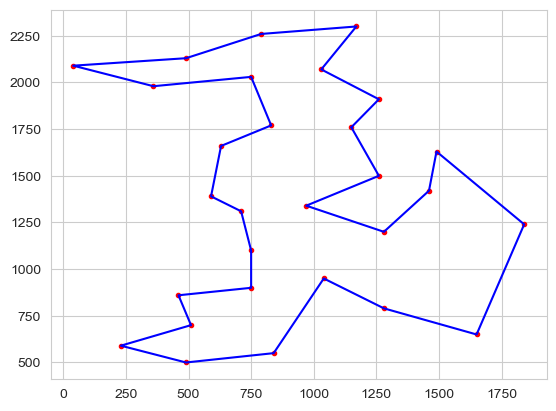

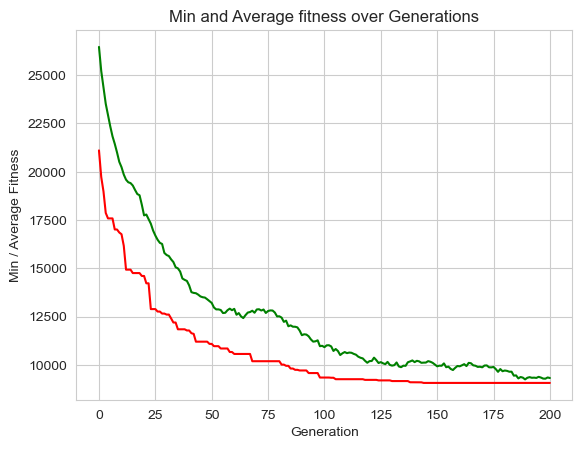

In [60]:
# plot best solution:
plt.figure(1)
tsp.plotData(best)

# plot statistics:
minFitnessValues, meanFitnessValues = logbook.select("min", "avg")
plt.figure(2)
sns.set_style("whitegrid")
plt.plot(minFitnessValues, color='red')
plt.plot(meanFitnessValues, color='green')
plt.xlabel('Generation')
plt.ylabel('Min / Average Fitness')
plt.title('Min and Average fitness over Generations')

# show both plots:
plt.show()

<div style="border: 2px solid #4CAF50; padding: 5px; border-radius: 4px; background-color: #e8f5e9; text-align: center;">
</div>

# **El Problema de Programación de Enfermer@s**

In [61]:
from deap import base
from deap import creator
from deap import tools

import random
import numpy

import matplotlib.pyplot as plt
import seaborn as sns

from Codigo_AG_py import elitism
from Codigo_AG_py import nurses

# problem constants:
HARD_CONSTRAINT_PENALTY = 10  # the penalty factor for a hard-constraint violation

# Genetic Algorithm constants:
POPULATION_SIZE = 300
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual
MAX_GENERATIONS = 200
HALL_OF_FAME_SIZE = 30

# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

toolbox = base.Toolbox()

# create the nurse scheduling problem instance to be used:
nsp = nurses.NurseSchedulingProblem(HARD_CONSTRAINT_PENALTY)

# define a single objective, maximizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)

# create an operator that randomly returns 0 or 1:
toolbox.register("zeroOrOne", random.randint, 0, 1)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initRepeat, creator.Individual, toolbox.zeroOrOne, len(nsp))

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)


# fitness calculation
def getCost(individual):
    return nsp.getCost(individual),  # return a tuple


toolbox.register("evaluate", getCost)

# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/len(nsp))


# Genetic Algorithm flow:

# create initial population (generation 0):
population = toolbox.populationCreator(n=POPULATION_SIZE)

# prepare the statistics object:
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", numpy.min)
stats.register("avg", numpy.mean)

# define the hall-of-fame object:
hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

# perform the Genetic Algorithm flow with hof feature added:
population, logbook = elitism.eaSimpleWithElitism(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                              ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

   

gen	nevals	min	avg    
0  	300   	689	1158.77
1  	245   	689	1028.02
2  	239   	538	909.587
3  	229   	489	803.7  
4  	247   	445	729.993
5  	239   	342	667.38 
6  	250   	342	597.19 
7  	252   	272	532.763
8  	249   	264	465.397
9  	250   	224	411.48 
10 	245   	217	357.667
11 	255   	134	317.667
12 	246   	134	280.203
13 	237   	103	251.517
14 	248   	103	229.01 
15 	249   	103	203.493
16 	248   	103	183.67 
17 	248   	95 	169.177
18 	240   	86 	152.1  
19 	240   	74 	139.787
20 	246   	73 	121.847
21 	242   	63 	109.88 
22 	245   	63 	103.863
23 	239   	52 	98.3333
24 	238   	52 	91.6767
25 	248   	31 	85.5867
26 	245   	31 	78.7767
27 	248   	31 	73.26  
28 	241   	31 	70.0667
29 	233   	31 	64.95  
30 	242   	31 	60.83  
31 	257   	30 	57.6833
32 	247   	29 	52.62  
33 	248   	21 	48.8367
34 	241   	19 	46.5733
35 	247   	16 	43.5   
36 	251   	14 	41.1533
37 	249   	14 	38.84  
38 	252   	13 	35.44  
39 	253   	13 	33.3367
40 	255   	13 	32.13  
41 	254   	12 	31.07  
42 	243   	

In [62]:
 # print best solution found:
best = hof.items[0]
print("\n-- Best Individual = ", best)
print("\n\n-- Best Fitness = ", best.fitness.values[0])
print()
print("-- Schedule = ")
nsp.printScheduleInfo(best)

# extract statistics:
minFitnessValues, meanFitnessValues = logbook.select("min", "avg")


-- Best Individual =  [0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0]


-- Best Fitness =  3.0

-- Schedule = 
Schedule for each nurse:
A : [0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
B : [1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0]
C : [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1]
D : [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0]
E : [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
F : [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0

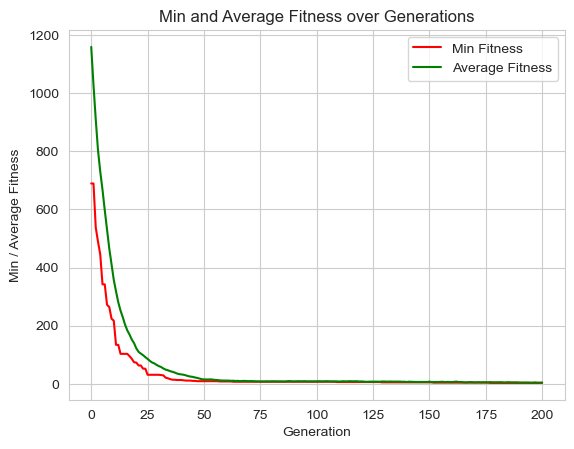

In [63]:
# plot statistics:
sns.set_style("whitegrid")

plt.plot(minFitnessValues, color='red', label='Min Fitness')
plt.plot(meanFitnessValues, color='green', label='Average Fitness')

plt.xlabel('Generation')
plt.ylabel('Min / Average Fitness')
plt.title('Min and Average Fitness over Generations')

plt.legend()  # <-- Agrega la leyenda

plt.show()


<div style="border: 2px solid #4CAF50; padding: 5px; border-radius: 4px; background-color: #e8f5e9; text-align: center;">
</div>

# **Optimización de Funciones Continuas**

### Minimización de la función Eggholder

$$
f(x, y) = -(y+47)\,\sin\left(\sqrt{\left|\frac{x}{2} + (y+47)\right|}\right)
          - x\,\sin\left(\sqrt{\left|x - (y+47)\right|}\right)
$$



In [64]:
from deap import base
from deap import creator
from deap import tools

import random
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from Codigo_AG_py import elitism

### El programa inicia estableciendo las constantes de la función, 
- específicamente el número de dimensiones de entrada: 2, dado que esta función se define sobre el plano $x$-$$
- y los límites que que son $-512.0, \ 512.0$.


In [65]:
# problem constants:
DIMENSIONS = 2  # number of dimensions
BOUND_LOW, BOUND_UP = -512.0, 512.0  # boundaries for all dimensions

### Se inicia con los siguientes parámetros para la configuración del algoritmo genético. 
- Debido a que la función Eggholder puede resultar algo difícil de optimizar,
- se utiliza un tamaño de población relativamente grande,
- especialmente considerando que el número de dimensiones es bajo.


In [66]:
# Genetic Algorithm constants:
POPULATION_SIZE = 300
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # (try also 0.5) probability for mutating an individual
MAX_GENERATIONS = 300
HALL_OF_FAME_SIZE = 30

### Además de las constantes habituales del algoritmo genético, se requiere ahora un nuevo parámetro: 
- el factor de crowding (*eta*), el cual es utilizado tanto en la operación de cruce como en la de mutación. 

> También es posible definir factores de crowding independientes para el cruce y para la mutación.


In [67]:
CROWDING_FACTOR = 20.0  # crowding factor for crossover and mutation

# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

toolbox = base.Toolbox()

# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)

### Dado que se trabaja con números de punto flotante restringidos por ciertos límites, 
- se define a continuación una función auxiliar que genera valores aleatorios de punto flotante
- distribuidos uniformemente dentro del rango especificado. 

> Esta función asume que los límites superior e inferior son iguales para todas las dimensiones.


In [68]:
# helper function for creating random real numbers uniformly distributed within a given range [low, up]
# it assumes that the range is the same for every dimension
def randomFloat(low, up):
    return [random.uniform(l, u) for l, u in zip([low] * DIMENSIONS, [up] * DIMENSIONS)]

### A continuación, se define el operador `attrFloat`. 
- Este operador utiliza la función auxiliar previamente creada para generar un único valor aleatorio de punto flotante dentro de los límites especificados.
- El operador `attrFloat` es utilizado posteriormente por el operador `individualCreator` para generar individuos aleatorios.
- Después de esto, interviene `populationCreator`, encargado de producir la cantidad deseada de individuos.


In [69]:
# create an operator that randomly returns a float in the desired range and dimension:
toolbox.register("attrFloat", randomFloat, BOUND_LOW, BOUND_UP)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initIterate, creator.Individual, toolbox.attrFloat)

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)

### Dado que el objetivo a minimizar es la función Eggholder, esta se utiliza directamente como evaluador de aptitud.

- Como cada individuo es una lista de valores de punto flotante con una dimensión (o longitud) de 2,
- se extraen de manera correspondiente los valores de $ x $ y $ y $ del individuo, y luego se procede a calcular la función.


In [70]:
# Eggholder function as the given individual's fitness:
def eggholder(individual):
    x = individual[0]
    y = individual[1]
    f = (-(y + 47.0) * np.sin(np.sqrt(abs(x/2.0 + (y + 47.0)))) - x * np.sin(np.sqrt(abs(x - (y + 47.0)))))
    return f,  # return a tuple

toolbox.register("evaluate", eggholder)

## A continuación, se presentan los operadores genéticos. 
- Dado que el operador de selección es independiente del tipo de individuo,
- y considerando que hasta ahora se ha obtenido un buen desempeño utilizando la selección por torneo con un tamaño de torneo igual a 2,
- junto con un enfoque elitista, se decide continuar con esta estrategia. 

### Por otro lado, los operadores de cruce y mutación requieren especialización
- para trabajar con números de punto flotante restringidos por límites específicos.
- Por esta razón, se emplea el operador `cxSimulatedBinaryBounded` proporcionado por DEAP para el cruce,
- y el operador `mutPolynomialBounded` para la mutación.


In [71]:
# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR, indpb=1.0/DIMENSIONS)


# Genetic Algorithm flow:

# create initial population (generation 0):
population = toolbox.populationCreator(n=POPULATION_SIZE)

# prepare the statistics object:
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", np.min)
stats.register("avg", np.mean)

# define the hall-of-fame object:
hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

### Como se ha realizado en múltiples ocasiones, 
- se utiliza una versión modificada del flujo básico de algoritmo genético de DEAP, en la cual se incorpora el elitismo.
- Este mecanismo conserva a los mejores individuos (miembros del *hall of fame*) y los transfiere a la siguiente generación sin que sean alterados por los operadores genéticos.


In [72]:
# perform the Genetic Algorithm flow with elitism:
population, logbook = elitism.eaSimpleWithElitism(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                              ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

gen	nevals	min     	avg    
0  	300   	-938.344	5.74366
1  	245   	-938.344	-107.035
2  	244   	-938.344	-194.829
3  	251   	-938.344	-251.261
4  	250   	-938.344	-294.323
5  	251   	-938.344	-361.511
6  	233   	-938.344	-428.505
7  	244   	-938.344	-533.703
8  	256   	-953.949	-546.139
9  	246   	-953.949	-620.07 
10 	251   	-954.639	-706.389
11 	246   	-954.639	-775.065
12 	247   	-954.943	-765.543
13 	243   	-955.505	-773.921
14 	250   	-956.204	-785.619
15 	242   	-956.269	-788.4  
16 	237   	-956.269	-811.097
17 	242   	-956.269	-859.935
18 	244   	-956.331	-883.166
19 	245   	-956.402	-902.298
20 	241   	-956.402	-890.983
21 	246   	-956.402	-916.914
22 	248   	-956.41 	-914.176
23 	230   	-956.41 	-913.174
24 	258   	-956.41 	-905.963
25 	240   	-956.415	-903.579
26 	253   	-956.416	-904.171
27 	247   	-956.416	-908.573
28 	262   	-956.416	-896.797
29 	249   	-956.416	-890.515
30 	249   	-956.416	-892.158
31 	248   	-956.418	-900.733
32 	241   	-956.418	-905.919
33 	251   	-956.

In [73]:
# print info for best solution found:
best = hof.items[0]
print("\n-- Best Individual = ", best)
print("-- Best Fitness = ", best.fitness.values[0])


-- Best Individual =  [512.0, 404.2315520362642]
-- Best Fitness =  -959.6406626480391


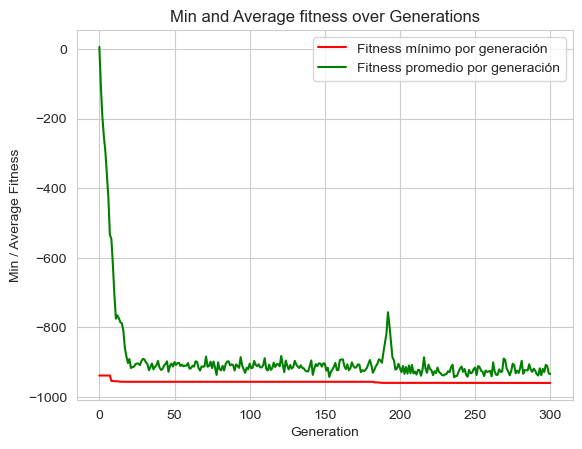

In [74]:
# extract statistics:
minFitnessValues, meanFitnessValues = logbook.select("min", "avg")

# plot statistics:
sns.set_style("whitegrid")

plt.plot(minFitnessValues, color='red', label='Fitness mínimo por generación')
plt.plot(meanFitnessValues, color='green', label='Fitness promedio por generación')

plt.xlabel('Generation')
plt.ylabel('Min / Average Fitness')
plt.title('Min and Average fitness over Generations')

plt.legend()  # <-- Aquí se agrega la leyenda

plt.show()


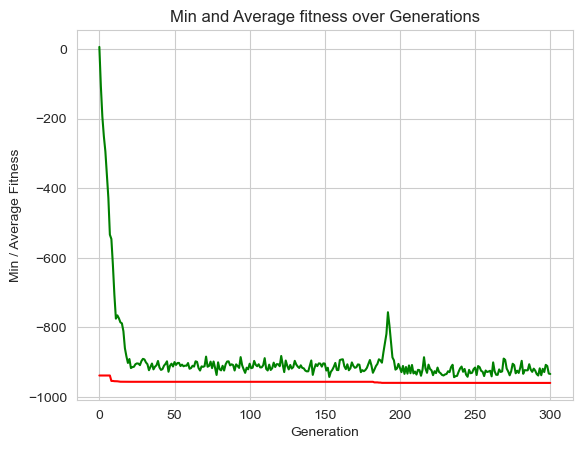

In [75]:
# plot statistics:
sns.set_style("whitegrid")
plt.plot(minFitnessValues, color='red')
plt.plot(meanFitnessValues, color='green')
plt.xlabel('Generation')
plt.ylabel('Min / Average Fitness')
plt.title('Min and Average fitness over Generations')

plt.show()

# RECONSTRUCCIÓN DE IMÁGENES

## Reconstructing images with polygons

In [76]:
from deap import base
from deap import creator
from deap import tools

import random
import numpy
import os

from Codigo_AG_py import image_test
from Codigo_AG_py import elitism_callback

import matplotlib.pyplot as plt
import seaborn as sns

# problem related constants
POLYGON_SIZE = 3
NUM_OF_POLYGONS = 100

# calculate total number of params in chromosome:
# For each polygon we have:
# two coordinates per vertex, 3 color values, one alpha value
NUM_OF_PARAMS = NUM_OF_POLYGONS * (POLYGON_SIZE * 2 + 4)

# Genetic Algorithm constants:
POPULATION_SIZE = 200
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.5   # probability for mutating an individual
MAX_GENERATIONS = 5000
HALL_OF_FAME_SIZE = 20
CROWDING_FACTOR = 10.0  # crowding factor for crossover and mutation

# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# create the image test class instance:
imageTest = image_test.ImageTest("fig/Notebook/Homer.jpg", POLYGON_SIZE)

# calculate total number of params in chromosome:
# For each polygon we have:
# two coordinates per vertex, 3 color values, one alpha value
NUM_OF_PARAMS = NUM_OF_POLYGONS * (POLYGON_SIZE * 2 + 4)

# all parameter values are bound between 0 and 1, later to be expanded:
BOUNDS_LOW, BOUNDS_HIGH = 0.0, 1.0  # boundaries for all dimensions

toolbox = base.Toolbox()

# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)

# helper function for creating random real numbers uniformly distributed within a given range [low, up]
# it assumes that the range is the same for every dimension
def randomFloat(low, up):
    return [random.uniform(l, u) for l, u in zip([low] * NUM_OF_PARAMS, [up] * NUM_OF_PARAMS)]

# create an operator that randomly returns a float in the desired range:
toolbox.register("attrFloat", randomFloat, BOUNDS_LOW, BOUNDS_HIGH)

# create an operator that fills up an Individual instance:
toolbox.register("individualCreator",
                 tools.initIterate,
                 creator.Individual,
                 toolbox.attrFloat)

# create an operator that generates a list of individuals:
toolbox.register("populationCreator",
                 tools.initRepeat,
                 list,
                 toolbox.individualCreator)


# fitness calculation using MSE as difference metric:
def getDiff(individual):
    return imageTest.getDifference(individual, "MSE"),
    #return imageTest.getDifference(individual, "SSIM"),

toolbox.register("evaluate", getDiff)


# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)

toolbox.register("mate",
                 tools.cxSimulatedBinaryBounded,
                 low=BOUNDS_LOW,
                 up=BOUNDS_HIGH,
                 eta=CROWDING_FACTOR)

toolbox.register("mutate",
                 tools.mutPolynomialBounded,
                 low=BOUNDS_LOW,
                 up=BOUNDS_HIGH,
                 eta=CROWDING_FACTOR,
                 indpb=1.0/NUM_OF_PARAMS)


# save the best current drawing every 100 generations (used as a callback):
def saveImage(gen, polygonData):

    # only every 100 generations:
    if gen % 100 == 0:

        # create folder if does not exist:
        folder = "fig/Notebook//results/run-{}-{}".format(POLYGON_SIZE, NUM_OF_POLYGONS)
        if not os.path.exists(folder):
            os.makedirs(folder)

        # save the image in the folder:
        imageTest.saveImage(polygonData,
                            "{}/after-{}-gen.png".format(folder, gen),
                            "After {} Generations".format(gen))

# Genetic Algorithm flow:

    # create initial population (generation 0):
population = toolbox.populationCreator(n=POPULATION_SIZE)

# prepare the statistics object:
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", numpy.min)
stats.register("avg", numpy.mean)

# define the hall-of-fame object:
hof = tools.HallOfFame(HALL_OF_FAME_SIZE)


# perform the Genetic Algorithm flow with elitism and 'saveImage' callback:
population, logbook = elitism_callback.eaSimpleWithElitismAndCallback(population,
                                                    toolbox,
                                                    cxpb=P_CROSSOVER,
                                                    mutpb=P_MUTATION,
                                                    ngen=MAX_GENERATIONS,
                                                    callback=saveImage,
                                                    stats=stats,
                                                    halloffame=hof,
                                                    verbose=True)

ModuleNotFoundError: No module named 'skimage'

In [ ]:
# print best solution found:
best = hof.items[0]
print()
print("Best Solution = ", best)
print("Best Score = ", best.fitness.values[0])
print()

In [ ]:
# draw best image next to reference image:
imageTest.plotImages(imageTest.polygonDataToImage(best))

In [ ]:
# extract statistics:
minFitnessValues, meanFitnessValues = logbook.select("min", "avg")

# plot statistics:
sns.set_style("whitegrid")
plt.figure("Stats:")
plt.plot(minFitnessValues, color='red')
plt.plot(meanFitnessValues, color='green')
plt.xlabel('Generation')
plt.ylabel('Min / Average Fitness')
plt.title('Min and Average fitness over Generations')

# show both plots:
plt.show()